# **Identifying Key Entities in Recipe Data**

- **Analysis performed by :-** Russel Reynold Chandanshiv

---

- Copyright (c) 2026 Russel Reynold Chandanshiv
- Licensed under the MIT License
  
---

### **Business Objective & Strategic Impact**

**The Core Objective:**
The primary goal of this project is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from unstructured recipe text. By classifying individual words into predefined categories—**Ingredients, Quantities, and Units**—the pipeline transforms messy, human-written recipes into a clean, structured database.

**Strategic Business Impact:**
Bridging the gap between unstructured culinary text and actionable data provides massive scalability for modern food-tech businesses. Automating this extraction eliminates the need for expensive, labor-intensive manual tagging and powers several high-value use cases:

* **E-Commerce & Grocery Platforms:** Enables the automatic generation of precise, shoppable ingredient lists from any online recipe, driving seamless user conversions and inventory management.
* **Health & Dietary Tracking Apps:** Empowers automated nutritional and macro calculators. By accurately isolating exact quantities and units, health apps can calculate precise caloric values without user friction.
* **Smart Recipe Management:** Allows digital food platforms to offer advanced features like dynamic recipe scaling (e.g., automatically halving or doubling a recipe), precise allergen filtering, and intelligent AI cooking assistants.

---

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |

---

## **1** **Installation & Environment Setup**

To run this pipeline, you will need to install **sklearn-crfsuite**. This is a high-level Python wrapper for **CRFsuite**, a fast and efficient implementation of Conditional Random Fields (CRFs). It is specifically designed to integrate seamlessly with the `scikit-learn` ecosystem for structured prediction tasks such as:

* **Named Entity Recognition (NER)** (The core of this project)
* **Part-of-Speech (POS) Tagging**
* **Chunking**

#### **1.1** **Install the dependency:**

```bash
pip install sklearn-crfsuite

In [1]:
# Consider Pre-installing the following libraries
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# installation of sklearn_crfsuite
# !pip install sklearn_crfsuite==0.5.0
# !pip install spacy

#### **Styling and Output Readability**

- **Console Formatting Utility:** Implemented a lightweight `color class` using ANSI escape codes to programmatically apply bold styling to terminal and notebook outputs, enhancing the visual hierarchy and scannability of key pipeline milestones.

In [2]:
# Styling for readability (BOLD)
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
class color:
    BOLD = "\033[1m"
    END = "\033[0m"
    

#### **Persistent Logging and Pipeline Initialization**

- **Standardized Logging Utility:** Developed a custom `log_progress` function to manage pipeline notifications across five severity levels (`DEBUG to CRITICAL`). This ensures all execution milestones are captured consistently in a centralized external text file for persistent record-keeping.

- **Environmental Isolation:** Configured the logging system to suppress notebook propagation, keeping the interactive interface clean while maintaining a high-fidelity audit trail of every internal operation.

- **Temporal Auditing:** Integrated automated timestamping to record the exact initiation and progression of the pipeline. This provides a chronological record of the workflow and enables precise calculation of the total execution runtime upon completion.

In [3]:
# Custom Logging Function
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Importing Libraries
import time
import logging
from datetime import datetime

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Configuration
logfile = "russel_key_entity_recipe_log.txt"

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Clear previous handlers (If any) and Do not display logs in notebook
logger = logging.getLogger(__name__)
logger.handlers.clear()
logger.propagate = False

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def log_progress(msg, level="info"):
    """
    Docstring: 
               Take's a message and the level of logging and creates a new file or appends existing file.
               Default Level for Logging : "INFO"
    Parameters:
               (Message, Level)
    Arguements:
               Message can be anything. Level must be valid.
               Level : ["Debug", "Info", "Warning", "Error", "Critical"]
    """
    level = level.upper().strip()

    if level == "DEBUG":
        logger.debug(msg)
        
    elif level == "INFO":
        logger.info(msg)
        
    elif level == "WARNING":
        logger.warning(msg)
        
    elif level == "ERROR":
        logger.error(msg)
        
    elif level == "CRITICAL":
        logger.critical(msg)
        
    else:
        level = "INFO"
        logger.info(msg)

    timeformat = '%Y-%b-%d-%H:%M:%S'
    timestamp = datetime.now().strftime(timeformat)
    with open(logfile, 'a') as f:
        f.write(f"{timestamp} | {level:^7} | {msg}\n")
        
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Recording the Start Time and Logging

start_time = time.time()
log_progress ("(1.1) Log Setup Completed Successfully : Logs will now be written to log file.")
print ("Log Setup Completed Successfully : Logs will now be written to log file.")

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging the Exact Start Time

timeformat = '%Y-%b-%d-%H:%M:%S'
timestamp = datetime.now().strftime(timeformat)

log_progress (f"Start Time : {timestamp}\n")


Log Setup Completed Successfully : Logs will now be written to log file.


#### **1.2** **Import necessary libraries**

In [4]:
# Importing necessary Libraries
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
log_progress ("================================= Step 1 : Importing Necessary Libraries =================================", "INFO")  

try:
    # Import warnings
    import warnings
    warnings.filterwarnings('ignore')

    import os # Inteacting with Operating System
    import json  # For handling our JSON recipe data
    import tqdm  # Smart Progress Bar
    import pandas as pd  # For data manipulation and analysis
    import re  # For regular expressions (useful for text preprocessing)
    import matplotlib.pyplot as plt  # For visualisation
    import seaborn as sns  # For advanced data visualisation
    import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
    import numpy as np  # For numerical computations
    
    # Saving and loading machine learning models
    import joblib
    import random
    import spacy # Advanced NLP Tasks
    from IPython.display import display, Markdown # For displaying well-formatted output

    from fractions import Fraction  # For handling fractional values in numerical data
    
    # Importing tools for feature engineering and model training
    from collections import Counter  # For counting occurrences of elements in a list
    from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
    from sklearn_crfsuite import metrics  # For evaluating CRF models
    from sklearn_crfsuite.metrics import flat_classification_report # Classification Report
    from sklearn.utils.class_weight import compute_class_weight
    from sklearn.metrics import accuracy_score # Accuracy Score
    from collections import Counter # Track Frequency
    from sklearn.metrics import confusion_matrix # Confusion Matrix

except Exception as e:
    print (f"The Exception is as follows :- {e}")
    log_progress ("There was an issue while importing libraries.", "WARNING")

else:
    print ("The libraries were imported successfully")
    log_progress ("(1.2) The libraries were imported successfully.\n")


The libraries were imported successfully


In [5]:
# Ensure pandas displays full content
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)


---

## **2** **Data Ingestion and Preparation**

In [6]:
log_progress ("================================ Step 2 : Data Ingestion and Preparation =================================", "INFO")  

---

### **2.1** **Data Ingestion, Preparation & Initial Structural Analysis**

- **JSON-to-DataFrame Conversion:** Implemented a robust data loading mechanism to ingest raw recipe data from JSON format and transform it into a structured Pandas DataFrame for high-performance processing.
  
- **Integrity Inspection:** Conducted an initial audit of the dataset by inspecting the first five observations, ensuring that the feature set (e.g., `input` and `pos`) was correctly aligned with the expected schema.
  
- **Descriptive Exploration:** Utilized statistical and structural summaries (`.describe()`) to verify the distribution of sequences, total observation counts, and the baseline characteristics of the recipe data prior to tokenization.


---

####  **2.1.1** **Engineering a Reusable Data Ingestion Utility**

- **Core Utility:** Built a modular function to handle the opening and reading of JSON recipe files, converting them directly into Pandas DataFrames.
  
- **Internal Documentation & Execution Monitoring:** Included structured docstrings for clarity and maintainability, along with lightweight logging to monitor ingestion success during execution.


In [7]:
# Function: Loads JSON file to a Pandas DataFrame (User provides File Path / File Name)
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def load_json_dataframe(file_path):
    """
    Docstring: 
               Loads data from a JSON file and converts it to a Pandas DataFrame.
    Parameters:
               (File Path/File Name - str) : The Path to the JSON file.
    Returns:
               A Pandas DataFrame ready for analysis.
    Example:
               df = load_json_dataframe("ingredient_and_quantity.json")
    """
    
    # Open and Read JSON Recipe Data
    with open(file_path, 'r') as file:
        data = json.load(file)
        return pd.DataFrame(data)
        
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging our Function 
log_progress ("(2.1.1) Custom Reusable Function - Loads a JSON file and converts it to a Pandas DataFrame.", "DEBUG")
print ("Custom Reusable Function - Loads a JSON file and converts it to a Pandas DataFrame.")


Custom Reusable Function - Loads a JSON file and converts it to a Pandas DataFrame.


#### **2.1.2** **Function Execution and Data Validation**

- **Error-Resilient Loading:** Executed the ingestion utility within a `try-except-else` block to handle potential I/O errors or missing files, ensuring the pipeline fails gracefully with descriptive warnings.

- **Data Validation:** Performed post-ingestion sanity checks by sampling records to verify feature integrity `(input tokens and POS tags)`, ensuring correct dataset structure before downstream processing.

In [8]:
# Reading the JSON file (using file name/path) with our function and converting to a Pandas DataFrame
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    df = load_json_dataframe("ingredient_and_quantity.json")

except Exception as e:
    print (f"The File couldn't be read because {e}")
    log_progress (f"The JSON File couldn't be read because {e}.", "WARNING")
     
else:
    print ("The JSON File has been read and converted to a Pandas DataFrame successfully.")
    log_progress ("(2.1.2) The JSON File has been read and converted to a Pandas DataFrame successfully.")
    

The JSON File has been read and converted to a Pandas DataFrame successfully.


In [9]:
# Let's view random 5 rows/observations in our dataset
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "These are 5 Randomly Selected Observations from our Dataset:-\n"+ color.END)
display (df.sample(5, random_state=42).reset_index(drop= True))


These are 5 Randomly Selected Observations from our Dataset:-



,input,pos
0,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry,quantity unit ingredient ingredient quantity ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient quantity ingredient ingredient unit ingredient
1,12 Baby Potatoes 1 Dry Red Chilli teaspoon Cumin seeds sprig Curry leaves Coriander Powder 1/2 Turmeric powder Garam masala Amchur Mango Lemon juice 3 tablespoons Leaves chopped,quantity ingredient ingredient quantity ingredient ingredient ingredient unit ingredient ingredient unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient
2,2 cups Brown Rice cooked tablespoons Garlic chopped 1 Green Chilli 1/2 cup Carrots (Gajjar) beans (French Beans) Bell Pepper (Capsicum) Onion Cabbage (Patta Gobi/ Muttaikose) tablespoon Roasted tomato pasta sauce - or store bought Red teaspoon Soy Ginger freshly grated Spring Greens Salt Vinegar Extra Virgin Olive Oil as required,quantity unit ingredient ingredient ingredient unit ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
3,200 grams Button mushrooms 1 Potato Aloo Onion Green Chilli inch Ginger teaspoon Sunflower Oil cup All Purpose Flour Maida,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient unit ingredient ingredient unit ingredient ingredient ingredient ingredient
4,5 Hog Plum Amtekai Ambade 3/4 cup Fresh coconut grated 1/4 teaspoon Turmeric powder Haldi 1 tablespoon Coriander Dhania Seeds Black Urad Dal Split Rice raw Methi Fenugreek 6 Whole Peppercorns 4 Dry Red Chilli 2 tablespoons Jaggery pinch Asafoetida hing Karela Bitter Gourd Pavakkai Small teaspoons Sunflower Oil 1/2 Mustard seeds,quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient quantity ingredient ingredient


#### **2.1.3 Exploratory Data Profiling and Schema Verification**

- **Initial Data Inspection:** Reviewed sample records to confirm correct alignment between raw recipe text (input) and corresponding sequence labels (pos).

- **Dataset Overview:** Assessed dataset size and structure `(285 observations, 2 features)` to establish baseline dimensions for downstream processing.

- **Schema Validation:** Verified data types and structure using Pandas utilities, ensuring both features were correctly interpreted as text data for tokenization.

In [10]:
# Let's view the first 5 rows/observations in our dataset
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "These are first 5 Observations from our Dataset:-\n"+ color.END)
display (df.head(5))


These are first 5 Observations from our Dataset:-



,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [11]:
# Number of Rows and Columns in our DataFrame [Dimensions]
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (f"The Dimensions of  the DataFrame is: {df.shape}.")
print (f"The DataFrame has {df.shape[0]:,} Observations and {df.shape[1]} Features.")
log_progress (f"(2.1.3) The DataFrame has {df.shape[0]:,} Observations and {df.shape[1]} Features {df.columns.tolist()}.")


The Dimensions of  the DataFrame is: (285, 2).
The DataFrame has 285 Observations and 2 Features.


In [12]:
# Let's view the Column Names 
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "The List of all the features present in our Dataset:-\n"+ color.END)
df.columns.tolist()


The List of all the features present in our Dataset:-



['input', 'pos']

In [13]:
# Let's view information about our dataset
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "The information of our Dataframe is as follows:-\n"+ color.END)
df.info()


The information of our Dataframe is as follows:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.1.4 Data Completeness and Missing Value Analysis**

- **Missing Value Assessment:** Evaluated the dataset for null entries across all features, confirming a `100% completeness rate with no missing values` in both input and pos columns.

- **Data Readiness:** Established that no imputation or data cleaning was required, allowing seamless progression into feature engineering.

In [14]:
# Missing Value Analysis: Proportion of Missing values in each feature
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
for cols in df.columns:
    missing_value = df[cols].isnull().sum()
    
    if missing_value >= 1:
        print (f"Column Name : {cols}  , Number of missing value : {missing_value:,} , Percentage of Missing Value : {missing_value/df[cols].shape[0] * 100:.2f}%")
        print ()
    else:
        print (f"Column Name : {cols}  , Percentage of Missing Value : {missing_value/df[cols].shape[0] * 100:.2f}%")
        print ()
        

Column Name : input  , Percentage of Missing Value : 0.00%

Column Name : pos  , Percentage of Missing Value : 0.00%



In [15]:
# Total Number of Missing Values in our Dataset
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (f"Percentage of Missing Values in our Dataset: {df.isnull().sum().sum()/df[cols].shape[0] * 100:.2f}%")
print ()
print (f"Total Number of Missing Values in our Dataset: {df.isnull().sum().sum()} Missing Values.")

log_progress (f"(2.1.4) Total Number of Missing Values in our Dataset: {df.isnull().sum().sum()} Missing Values ({df.isnull().sum().sum()/df[cols].shape[0] * 100:.2f}%).", "INFO")


Percentage of Missing Values in our Dataset: 0.00%

Total Number of Missing Values in our Dataset: 0 Missing Values.


---

### **2.2** **Recipe Data Manipulation and Pipeline Preprocessing**

- **Derived Metric Engineering:** This phase focuses on transforming raw, human-written recipe strings into structured, tokenized sequences. By engineering metrics such as `input_tokens` and `pos_tokens`, the pipeline prepares the data for high-performance sequence labeling.

- **Structural Integrity Auditing:** Implementation of rigorous length-based validation to ensure perfect `1-to-1 mapping` between tokens and their corresponding entity labels. This step is critical for maintaining the mathematical constraints required by the Conditional Random Field (CRF) architecture.

- **Data Quality Optimization:** Identification and systematic pruning of anomalous observations, resulting in a refined, high-fidelity dataset of **280 validated sequences** optimized for model training and cross-validation.

---

#### **2.2.1 Feature Tokenization and Sequence Preparation**

- **Sequence Tokenization:** Converted raw recipe text (`input`) and corresponding labels (`pos`) into tokenized sequences using whitespace splitting, generating aligned token lists (`input_tokens` and `pos_tokens`) for sequence labeling.

- **Transformation Validation:** Verified the correctness of tokenization by inspecting sample records to ensure token-level alignment between inputs and labels.

In [16]:
# Tokenization : Splitting [input_tokens and pos_tokens] in the DataFrame (Derived Metric)
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Tokenize input
    df["input_tokens"] = df["input"].str.split()
    
    # Tokenize POS
    df["pos_tokens"]   = df["pos"].str.split()
    
except Exception as e:
    print(f"Error during the process of Tokenization: {e}")
    log_progress(f"Error during the process of Tokenization: {e}", "ERROR")

else:
    # Logging Tokenization
    log_progress (f"(2.2.1) Tokenization of the Input and POS features completed successfully.", "INFO")
    
    # Print Statement upon Successful Completion
    print (f"Tokenization of the Input and POS features completed successfully.")
    

Tokenization of the Input and POS features completed successfully.


In [17]:
# Let's view the first 5 rows/observations in our dataset [After Tokenization]
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "These are first 5 Observations [After Tokenization] from our Dataset:-\n"+ color.END)
display (df.head(5))


These are first 5 Observations [After Tokenization] from our Dataset:-



,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

#### **2.2.2 Sequence Length Validation and Mapping Integrity**

- **Sequence Length Analysis:** Computed token counts for both input and label sequences `(input_length, pos_length)` to enable structural validation.

- **Alignment Validation:** Identified mismatches between token and label sequence lengths, `isolating 5 anomalous observations` where 1-to-1 alignment was violated, ensuring only correctly aligned data progressed to the training stage.

In [18]:
# Create input_length and pos_length columns for the input_tokens and pos_tokens
# Check for the equality of input_length and pos_length in the dataframe
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Creating Length Feature (input_length)
    df["input_length"] = df["input_tokens"].str.len()

    # Creating Length Feature (pos_length)
    df["pos_length"]   = df["pos_tokens"].str.len()

    # Length Validation [Checking for Rows with Length Mismatch]
    length_mismatch = df[df["input_length"] != df["pos_length"]]

    # Checking and Logging of Mismatches
    if length_mismatch.shape[0] > 0:
        print (f"Warning: Mismatch is found, Number of Observations with Mismatch: {length_mismatch.shape[0]:,} Observations.")
        log_progress(f"(2.2.2) Mismatch is found, Number of Observations with Mismatch: {length_mismatch.shape[0]:,} Observations.", "WARNING")
    else:
        print (f"Success: No mismatch is present in the data. [1-to-1 Mapping]")
        log_progress(f"(2.2.2) Success: Validation Passed - No mismatch is present in the data. [1-to-1 Mapping]", "INFO")

except Exception as e:
    print(f"Error during the process of Length Validation: {e}")
    log_progress(f"(2.2.2) Error during the process of Length Validation: {e}", "ERROR")

else:
    # Let's view 2 Random Rows/Observations in our Dataset [After Validation]
    print (color.BOLD + "Let's view 2 Random Observations [After Validation] from our Dataset:-\n"+ color.END)
    display (df.sample(2, random_state= 42).reset_index(drop= True))
    
    # Let's view the Mismatches present in our Dataset [After Validation]
    print (color.BOLD + f"These are {length_mismatch.shape[0]} Mismatches [After Validation] from our Dataset:-\n"+ color.END)
    display (length_mismatch) 


(2.2.2) Mismatch is found, Number of Observations with Mismatch: 5 Observations.


Let's view 2 Random Observations [After Validation] from our Dataset:-



,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry,quantity unit ingredient ingredient quantity ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient quantity ingredient ingredient unit ingredient,"[1, cup, cabbage, leaves, 3/4, tomatoes, 18, grams, tamarind, 2, tablespoons, white, urad, dal, 4, red, chillies, 3, cloves, garlic, big, Spoon, oil, teaspoon, Rye, 1/2, Cumin, seeds, sprig, Curry]","[quantity, unit, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient]",30,30
1,12 Baby Potatoes 1 Dry Red Chilli teaspoon Cumin seeds sprig Curry leaves Coriander Powder 1/2 Turmeric powder Garam masala Amchur Mango Lemon juice 3 tablespoons Leaves chopped,quantity ingredient ingredient quantity ingredient ingredient ingredient unit ingredient ingredient unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient,"[12, Baby, Potatoes, 1, Dry, Red, Chilli, teaspoon, Cumin, seeds, sprig, Curry, leaves, Coriander, Powder, 1/2, Turmeric, powder, Garam, masala, Amchur, Mango, Lemon, juice, 3, tablespoons, Leaves, chopped]","[quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",28,28


These are 5 Mismatches [After Validation] from our Dataset:-



,input,pos,input_tokens,pos_tokens,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[2, cups, curd, 1, cup, gourd, cucumber, green, cor, coriander, 1/2, teaspoon, cumin, powder, salt]","[quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Baguette, sliced, 1, 1/2, tablespoon, Butter, 1/2, Garlic, minced, cup, Spinach, Leaves, Palak, Red, Bell, pepper, Capsicum, Tomato, finely, chopped, Onion, Black, powder, Italian, seasoning, teaspoon, Fresh, cream, Cheddar, cheese, grated, Salt, Roasted, tomato, pasta, sauce]","[quantity, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1/2, cup, Poha, Flattened, rice, 2, tablespoons, Rice, flour, 2, 1/2, liter, Milk, 1, Nolen, Gur, or, brown, sugar, Cardamom, Elaichi, Pods/Seeds, 8-10, Mixed, nuts, almonds/cashews, tablespoon, Raisins, pinch, Saffron, strands, and, a, little, more, for, garnish, Salt]","[quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[

#### **2.2.3 Label Space Extraction and Schema Validation**

- **Label Space Identification:** Extracted `unique POS labels` from the sequence data to establish the complete set of entities present in the dataset.

- **Schema Validation:** Confirmed the presence of the three core entity classes—`Quantity, Ingredient, and Unit`—verifying that the dataset follows a consistent and well-defined annotation structure for sequence labeling.

In [19]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def unique_labels(df):
    """
    Docstring: 
               Checks, Identifies and Extracts all unique POS Labels present in `pos_tokens` feature.
    Parameters:
               (df - Pandas DataFrame) : The Pandas DataFrame containing the `pos_tokens` feature.
    Returns:
               A tuple of unique POS labels.
    Example:
               tuple_of_unique_pos_labels = unique_labels(df)
    """
    # Creating an Empty Set (Purpose: Storing unique POS labels)
    unique_pos_labels = set()

    # Loop through each observation of our dataset (Add the POS labels to the Set)
    for labels in df["pos_tokens"]:
        unique_pos_labels.update(labels)

    # Returns Tuple (Immutable)
    return tuple(unique_pos_labels)
    
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Execution: Extracting the Unique POS Labels from our Dataset
try:
    # Extract: Unique POS Labels
    unique_pos_labels = unique_labels(df)

except Exception as e:
    print(f"Error during the process of Identification of POS Label: {e}")
    log_progress(f"(2.2.3) Error during the process of Identification of POS Labels: {e}", "ERROR")

else:
    # Display Unique Pos Labels
    print (color.BOLD + "The Unique POS (Part-of-Speech) labels are as follows:-\n" + color.END)

    # For Readability (Displaying with Index)
    for index,label in enumerate(unique_pos_labels):
        print (f"{index + 1}) {label.capitalize()}")

    # Logging [Identification of Unique POS Labels]
    log_progress(f"(2.2.3) Success: Unique POS Labels {unique_pos_labels} have been identified successfully.", "INFO")
    

The Unique POS (Part-of-Speech) labels are as follows:-

1) Quantity
2) Ingredient
3) Unit


#### **2.2.4 Data Integrity Insights and Anomaly Identification**

- **The Indexes that require Cleaning and Formatting in the DataFrame:** 17, 27, 79, 164, 207
- **The Total Number of Mismatches between Input Length and POS Length:** 5
- **Data Integrity:** In a valid Named Entity Recognition (NER), these lengths must be identical.
- **Reason for Same Length:** NER is a sequence labelling problem, each input token is assigned a corresponding POS tag.
- **Conclusion:** The observations with invalid data must be dropped in the next Data Cleaning step.

In [20]:
print (color.BOLD + "The Indexes that require Cleaning and Formatting in the DataFrame [Length Mismatch]:" + color.END + f" {length_mismatch.index.to_list()}\n")
log_progress(f"(2.2.4) The Indexes that require Cleaning and Formatting in the DataFrame [Length Mismatch]: {length_mismatch.index.to_list()}", "DEBUG")

for index in length_mismatch.index:
    print (color.BOLD + f"Index {index} " + color.END + f"(Input Length: {length_mismatch ["input_length"][index]}, POS Length: {length_mismatch ["pos_length"][index]})")
    

The Indexes that require Cleaning and Formatting in the DataFrame [Length Mismatch]: [17, 27, 79, 164, 207]

Index 17 (Input Length: 15, POS Length: 14)
Index 27 (Input Length: 37, POS Length: 36)
Index 79 (Input Length: 38, POS Length: 37)
Index 164 (Input Length: 54, POS Length: 53)
Index 207 (Input Length: 18, POS Length: 17)


#### **2.2.5 Data Pruning and Dataset Finalization**

- **Sequence Pruning:** `Removed 5 observations with token-label misalignment`, ensuring that only structurally valid sequences were retained for model training.

- **Dataset Finalization:** Confirmed a refined dataset of `280 high-quality observations`, establishing a clean and consistent input for downstream feature extraction and modeling.

In [21]:
# Drop the Irrelevant Recipe Data
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# The Number of Observations [Before Dropping]
print (color.BOLD + "The Number of Observations [Before Dropping] :" + color.END + f" {df.shape[0]}")

# Dropping Irrelevant Recipe Data [Mismatch - Input and POS Length]
df.drop(index= length_mismatch.index.to_list(), inplace= True)

# Resetting the Index
df.reset_index(drop=True, inplace=True)

# The Number of Observations [After Dropping]
print (color.BOLD + "The Number of Observations [After Dropping] :" + color.END + f" {df.shape[0]}")

# Logging (Drop of Irrelevant Recipe Data)
log_progress("(2.2.5) Observations with Irrelevant Recipe Data (Length Mismatch) was removed from our Dataset.", "INFO")


The Number of Observations [Before Dropping] : 285
The Number of Observations [After Dropping] : 280


#### **2.2.6 Length Feature Synchronization**

* **Feature Re-computation:** Updated the `input_length` and `pos_length` metrics to reflect the current state of the dataset following the removal of anomalous observations.
  
* **Metric Synchronization:** Synchronized token and label counts to ensure structural consistency before proceeding to the feature engineering phase.


In [22]:
# Update the input and pos length in input_length and pos_length
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Re-Calculating Length Feature (input_length) (after cleaning)
    df["input_length"] = df["input_tokens"].str.len()

    # Re-Calculating Length Feature (pos_length) (after cleaning)
    df["pos_length"]   = df["pos_tokens"].str.len()

except Exception as e:
    print(f"Error during the process of Updating Lengths: {e}")
    log_progress(f"(2.2.6) Error during the process of Updating Lengths: {e}", "ERROR")

else:
    # Let's view the first 5 rows/observations in our dataset [After Updating]
    print (color.BOLD + "These are first 5 Observations [After Updating] from our Dataset:-\n"+ color.END)
    display (df.head(5))

    # Logging Progress: Lengths Updated
    log_progress("(2.2.6) Success: Recomputed the Input and POS Length (After Dropping Mismatch).", "INFO")


These are first 5 Observations [After Updating] from our Dataset:-



,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",34,34
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",37,37
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient

#### **2.2.7** **Final Integrity Re-Validation**

- **Post-Cleaning Compliance Check:** Conducted a final programmatic scan for asymmetrical token-label sequences to ensure the refined dataset is `100% compliant with NER structural requirements`.

- **Integrity Confirmation:** Successfully verified that all remaining observations maintain `perfect 1-to-1 mapping`, effectively `greenlighting` the data for the feature engineering and model training phases.

In [23]:
# Re-Validate the input length and pos length as input_length and pos_length
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Re-Checking Length Validation [Checking for Rows with Length Mismatch]
    length_mismatch = df[df["input_length"] != df["pos_length"]]

    # Re-Checking and Logging of Mismatches
    if length_mismatch.shape[0] > 0:
        print (f"Warning: Mismatch is found, number of rows with mismatch {length_mismatch.shape[0]:,}")
        log_progress(f"(2.2.7) Mismatch is found, number of rows with mismatch {length_mismatch.shape[0]:,}\n", "WARNING")
    else:
        print (color.BOLD + "Success: Re-Validation Passed - " + color.END + "No mismatch is present in the data.")
        log_progress("(2.2.7) Success: Re-Validation Passed - No mismatch is present in the data.\n", "INFO")

except Exception as e:
    print(f"Error during the process of Length Re-Validation: {e}")
    log_progress(f"(2.2.7) Error during the process of Length Re-Validation: {e}\n", "ERROR")


Success: Re-Validation Passed - No mismatch is present in the data.


---

## **3.** **Train-Validation Strategy and Corpus Partitioning**

- **Evaluation Framework Implementation:** Established a robust data partitioning strategy to facilitate unbiased model training and performance benchmarking. By isolating a dedicated validation set, the pipeline ensures that model accuracy is measured on unseen data, mitigating the risk of overfitting.

- **Format Optimization for NLP Engines:** Managed the transition of raw data from high-level Pandas structures into the discrete list-based formats required by the `sklearn-crfsuite` library, ensuring seamless integration between the preprocessing and modeling layers.


In [24]:
# Logging: Phase 3 -- Train-Validation Data Split
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
log_progress ("================================== Step 3 : Train Validation Data Split ==================================", "INFO")


---

### **3.1** **Dataset Partitioning and Format Transition**


---

#### **3.1.1** **Train-Validation Partitioning and Integrity Verification**

- **Stochastic Data Stratification:** Partitioned the validated dataset into `training` (**`70%`**) and `validation` (**`30%`**) subsets using a fixed `random_state=42` to ensure reproducible results across multiple execution cycles.

- **Dataset Continuity Audit:** Implemented a sum-check validation to confirm that the aggregate observations of the split subsets (**`196`** `train,` **`84`** `validation)` perfectly match the original population of **`280`**, ensuring no data loss during the partitioning process.


In [25]:
# Performing Training and Validation Split using [70:30]
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Split Data -- Training and Validation Sets
try:
    train_df, val_df = train_test_split (df, test_size= 0.30, random_state= 42)

except Exception as e:
    # Logging: Error Message
    print(f"Error during Train-Validation Split: {e}")
    log_progress(f"(3.1.1) Error during Train-Validation Split: {e}", "ERROR")
    
else:
    # Logging: Success Message
    log_progress(f"(3.1.1) Success: Training and Validation Split performed successfully [70:30].", "INFO")
    print(color.BOLD + "Success: " + color.END + "Training and Validation Split performed sucessfully [70:30].")
    
# Verifying: Number of Observations
if train_df.shape[0] + val_df.shape[0] == df.shape[0]:
    print (color.BOLD + "Data Integrity [Training Set + Validation Set = Original Data Set] --> " + color.END + "Sanity Check Successful.")
    
print (color.BOLD + "\nThe Number of Observations in Training DataFrame: " + color.END + f"{train_df.shape[0]}")
print (color.BOLD + "The Number of Observations in Validation DataFrame: " + color.END + f"{val_df.shape[0]}")


Success: Training and Validation Split performed sucessfully [70:30].
Data Integrity [Training Set + Validation Set = Original Data Set] --> Sanity Check Successful.

The Number of Observations in Training DataFrame: 196
The Number of Observations in Validation DataFrame: 84


#### **3.1.2 Subset Distribution and Structural Inspection**

- **Split Validation:** Verified that token-label alignment and feature structure were preserved across both training and validation subsets following the data split.

In [26]:
log_progress("(3.1.2) Inspection of the first five observations: 'train_df' and 'val_df'", "DEBUG")

In [27]:
# Let's view the first 5 rows/observations in our train_df
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "These are first 5 Observations from our Training Dataset:-\n"+ color.END)
display (train_df.head(5))


These are first 5 Observations from our Training Dataset:-



,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, qua

In [28]:
# Let's view the first 5 rows/observations in our val_df
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "These are first 5 Observations from our Validation Dataset:-\n"+ color.END)
display (val_df.head(5))


These are first 5 Observations from our Validation Dataset:-



,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
259,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient i

#### **3.1.3** **Feature-Target Extraction and Format Conversion**

- **Data Format Transition:** Converted tokenized features and labels from Pandas Series into standard Python lists, satisfying the specific input requirements for sequence processing within the `sklearn-crfsuite` library.

- **Feature-Label Synchronization Audit:** Conducted a final volume validation to ensure that feature and target counts remain perfectly synchronized across both subsets `(196 training, 84 validation)`, confirming that the extraction process maintained the `1-to-1 relationship` between recipe tokens and their corresponding tags.

In [29]:
# Extract the training and validation sets by taking input_tokens and pos_tokens
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Extraction: Converting Pandas Series to List (Standard Practice -- Requirement of sklearn-crfsuite)
    X_train = train_df ["input_tokens"].tolist(); y_train = train_df ["pos_tokens"].tolist()
    X_val   = val_df ["input_tokens"].tolist()  ; y_val   = val_df ["pos_tokens"].tolist()

except Exception as e:
    print(f"Error during Extraction: {e}")
    log_progress(f"(3.1.3) Error during Extraction: {e}", "ERROR")

else:
    print(f"{color.BOLD}Extraction:{color.END} [X_train, y_train, X_val, y_val] Extracted Successfully (Standard Practice & Requirement).")
    log_progress("(3.1.3) Extraction: [X_train, y_train, X_val, y_val] Extracted Successfully (Standard Practice & Requirement).", "INFO")
    

Extraction: [X_train, y_train, X_val, y_val] Extracted Successfully (Standard Practice & Requirement).


In [30]:
# Validate the shape of training and validation samples
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Verifying: Number of Observations
if ((len(X_train) + len(X_val)) == df.shape[0]) & ((len(y_train) + len(y_val)) == df.shape[0]):
    print (color.BOLD + "Data Integrity [Training Set + Validation Set = Original Data Set] --> " + color.END + "Sanity Check Successful.")

    print ()

    print (color.BOLD + "The Total Number of Training Samples (X_train): " + color.END + f"{len(X_train)}")
    print (color.BOLD + "The Total Number of Training Samples (y_train): " + color.END + f"{len(y_train)}")

    print ()

    print (color.BOLD + "The Total Number of Validation Samples (X_val): " + color.END + f"{len(X_val)}")
    print (color.BOLD + "The Total Number of Validation Samples (y_val): " + color.END + f"{len(y_val)}")


Data Integrity [Training Set + Validation Set = Original Data Set] --> Sanity Check Successful.

The Total Number of Training Samples (X_train): 196
The Total Number of Training Samples (y_train): 196

The Total Number of Validation Samples (X_val): 84
The Total Number of Validation Samples (y_val): 84


#### **3.1.4 Training Label Space Audit and Taxonomy Verification**

- **Label Space Verification:** Extracted `unique labels from the training set` to ensure coverage of the complete entity vocabulary.

- **Class Representation Check:** Confirmed the presence of all three entity classes—`Quantity, Ingredient, and Unit`—ensuring the training data remains representative after the split.

In [31]:
# Display the number of unique labels present in y_train
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initializing an Empty Set (Automatically Filter ---> Set contains unique values - No Duplicates)
unique_labels = set()

# Iterating through the Nested List
for items in y_train:
    # Iterating through the String in the List
    for text in items:
        # Adding the Labels to the Set (Duplicates Ignored/Filtered Out)
        unique_labels.add(text)

print(color.BOLD + "Labels Found: " + color.END + f" {unique_labels}")
print (color.BOLD + "The Number of Unique Labels present in y_train: " + color.END + f"{len (unique_labels)} Labels.")
log_progress(f"(3.1.4) Unique Labels (y_train): {unique_labels}, Total Number of Unique Labels (y_train): {len (unique_labels)} Labels.\n", "INFO")


Labels Found:  {'quantity', 'ingredient', 'unit'}
The Number of Unique Labels present in y_train: 3 Labels.


---

## **4** **Exploratory Recipe Data Analysis on Training Dataset**


In [32]:
log_progress ("====================== Step 4 : Exploratory Recipe Data Analysis on Training Dataset =====================", "INFO")

---

### **4.1 Corpus Preparation via Sequence Flattening**

- **Sequence Flattening:** Transformed nested token and label sequences into a single contiguous list to enable corpus-level analysis across all observations.

- **Utility Implementation:** Applied a reusable list comprehension-based function to efficiently flatten `input_tokens` and `pos_tokens` for downstream statistical evaluation.

In [33]:
# Flatten the list for nested_list (input_tokens, pos_tokens)
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Custom Reusable Function - Flattening Nested List
def flatten_list(nested_list):
    """
    Docstring: 
               Converts a nested list (list of lists) into a single flat list.
    Parameters:
               Nested List (nested_list): Takes a list either (input_tokens or pos_tokens) and flattens it.
    Returns:
               A Single Flattened List.
    Example:
               flatten_list(nested_list)
    """
    return [text for subset_items in nested_list for text in subset_items]
    
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initialise the dataset_name
dataset_name = "Training"

# Logging: Custom Reusable Function - Flattening Nested List
log_progress ("(4.1) Custom Reusable Function - Flattening Nested List.", "DEBUG")
print (color.BOLD + "Custom Reusable Function - Flattening Nested List." + color.END)


Custom Reusable Function - Flattening Nested List.


### **4.2 Aggregate Corpus Validation and Sequence Alignment**

- **Corpus Consolidation:** Unified token and label sequences into flattened lists to enable corpus-level analysis of word-label distributions.

- **Alignment Validation:** Verified a `perfect 1:1 mapping across 7,114 tokens and labels`, with sample inspection confirming correct token-label alignment and extraction integrity.

In [34]:
# Define a extract_and_validate_tokens with parameters (df, dataset_name)
# Flatten's the Input Tokens and POS Tokens, Validates the Length to ensure 1:1 Mapping, Displays the frist 10 Tokens for both
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def extract_and_validate_tokens(df, dataset_name):
    """
    Docstring: 
              Extracts, Flattens, Validates tokens and labels from the provided dataset (Training/Validation).
    Parameters:
              df (pd.DataFrame): Pandas DataFrame. The DataFrame containing the Input and POS Tokens.
              dataset_name (str): The Label for the current dataset (Training/Validation).
    Returns:
              tuple: (flatten_input_tokens, flatten_pos_tokens)
              Two unified lists containing the flattened words and their corresponding labels.
    """
    try:
        # Step 1: Flattening both the Input and Target (input_tokens, pos_tokens)
        flatten_input_tokens = flatten_list(df ["input_tokens"].tolist()) # Re-Derived --> (This is X_train stores our input tokens)
        flatten_pos_tokens   = flatten_list(df ["pos_tokens"].tolist())   # Re-Derived --> (This is y_train stores our pos tokens)

        # Step 2: Validate Token Length [Ensures 1:1 Mapping, Prevents Mismatch]
        if len(flatten_input_tokens) == len(flatten_pos_tokens):
            print(color.BOLD + "Length Validation Successful." + color.END)
            print(f"Total tokens in {dataset_name} Set: {len(flatten_input_tokens):,}")
            print(f"Total labels in {dataset_name} Set: {len(flatten_pos_tokens):,}")
        else:
            print(color.BOLD + "Length Validation Failed [Length Mismatch]." + color.END)

    except Exception as e:
        print(f"Error during Flattening: {e}")
        log_progress(f"(4.2) Error during Flattening: {e}", "ERROR")

    else:
        print(color.BOLD + "EDA Status: " + color.END + f"{dataset_name} set flattened and validated successfully.\n")

        # Step 3: Display the First (10) Tokens for both
        print(color.BOLD + "First Ten Input Tokens: " + color.END + f"{flatten_input_tokens[:10]}")
        print(color.BOLD + "First Ten POS Tokens: " + color.END + f"{flatten_pos_tokens[:10]}")

        return flatten_input_tokens, flatten_pos_tokens

#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 4: Execution - Calling the function on the Training Dataset
try:
    training_input, training_pos = extract_and_validate_tokens(train_df, dataset_name)

except Exception as e:
    print(f"Error during extraction and validation: {e}")
    log_progress(f"Error during extraction and validation: {e}", "ERROR")

else:
    log_progress(f"(4.2) Flattened lists created for {dataset_name} dataset EDA. Length Validation Successful [Length Matched].", "INFO")
    

Length Validation Successful.
Total tokens in Training Set: 7,114
Total labels in Training Set: 7,114
EDA Status: Training set flattened and validated successfully.

First Ten Input Tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First Ten POS Tokens: ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


### **4.3 Entity-Specific Token Categorization**

- **Entity Segregation:** Partitioned the flattened token stream into separate lists for `ingredients, units, and quantities` to enable entity-level analysis.

- **Validation and Verification:** Ensured conformity to the expected label schema `(ingredient, unit, quantity)` and validated the categorization through sample inspection, confirming accurate grouping of tokens `(e.g., "Okra," "grams," "250")`.

In [35]:
# Reusable Function: Creates Ingredient, Unit and Quantity Lists (parameters ---> input_tokens, pos_tags)
# Validattion - Actual Vs Expected, returns empty list if it doesn't match
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def categorize_tokens(input_tokens, pos_tags):
    """
    Docstring: 
               Validates and Categorizes Flattened Tokens into Specific NER category lists.
    Parameters and Arguments:
               input_tokens (list): A flat list of strings representing recipe words.
               pos_tags (list): A flat list of strings representing the corresponding labels.
    Returns:
               tuple: (ingredient_list, unit_list, quantity_list)
               Each is a list of tokens belonging to that particular NER Category.
               Validation: Returns ([], [], []) if label validation fails.
    """
    
    # Validation: Actual Labels vs Expected Labels
    expected_labels = {"ingredient", "quantity", "unit"}
    actual_labels = {tag.lower() for tag in pos_tags}

    if not actual_labels.issubset(expected_labels):
        return list(), list(), list()

    # Initializing the POS Unique Labels
    ingredient = list(); unit = list(); quantity = list()

    # Extracting the Relevant Data for Each POS Label
    for input, pos in zip(input_tokens, pos_tags):
        if pos.lower() == "ingredient":
            ingredient.append(input)
        elif pos.lower() == "unit":
            unit.append(input)
        elif pos.lower() == "quantity":
            quantity.append(input)

    return ingredient, unit, quantity

#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Execution - Calling the function [Categorizing Labels into Respective List] on the Training Dataset
try:
    ingredient, unit, quantity = categorize_tokens(training_input, training_pos)

except Exception as e:
    print(f"Error during categorizing and validation: {e}")
    log_progress(f"Error during categorizing and validation: {e}", "ERROR")

else:
    print(color.BOLD + "Validation and Categorizing Tokens into Labels ['ingredient', 'quantity', 'unit'] Successful.\n" + color.END)
    log_progress(f"(4.3) Validation and Categorizing Tokens into Labels ['ingredient', 'quantity', 'unit'] Successful.", "INFO") 

    # Display the First (10) Tags
    print(color.BOLD + "First Ten Ingredient Tokens: " + color.END + f"{ingredient[:10]}")
    print(color.BOLD + "First Ten Quantity Tokens: " + color.END + f"{quantity[:10]}")
    print(color.BOLD + "First Ten Unit Tokens: " + color.END + f"{unit[:10]}")
    

Validation and Categorizing Tokens into Labels ['ingredient', 'quantity', 'unit'] Successful.

First Ten Ingredient Tokens: ['Okra', 'Oil', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated', 'Ginger', 'Garlic', 'Finely']
First Ten Quantity Tokens: ['250', '1', '2', '1/2', '1/4', '200', '2', '1', '1/2', '500']
First Ten Unit Tokens: ['grams', 'teaspoon', 'Teaspoon', 'cup', 'grams', 'tablespoon', 'teaspoon', 'grams', 'teaspoon', 'sprig']


### **4.4 Frequency Distribution Analysis**

- **Frequency Analysis & Top-K Identification:** Computed token frequency distributions for each entity class `(Ingredient, Unit, Quantity)` to understand the dominant vocabulary within the training corpus, extracting `the top 10 most frequent tokens per category`.

In [36]:
# Re-usable function: Extracts and Returns the Top 10 Items from a List (Based on Frequency)
# Parameters: item_list, pos_label, dataset_name
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def get_top_frequent_items(item_list, pos_label, dataset_name):
    """
    Docstring: 
               Calculates the frequency of items in a list and returns the top 10.
    Parameters:
               item_list (list): The list of tokens (ingredients or units or quantity)
               pos_label (str): The name of the category (for displaying)
               dataset_name (str): The split being analyzed (e.g., "Training" or "Validation")
    Returns:
               Top 10 (list): Top 10 most frequent items with their counts.
    """
    
    # Initializing an empty dictionary (Key ---> Item, Value ---> Frequency Count)
    dictionary = dict()
    
    if pos_label.lower() in {"ingredient", "quantity", "unit"}:
        for items in item_list:
            if items in dictionary:
                # If it exists (Add 1 Count to it)
                dictionary[items] += 1
            else:
                # If it doesn't exist create a key-value pair
                dictionary[items] = 1

    return sorted(dictionary.items(), key= lambda x: x[1], reverse=True)[:10]

#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Custom Reusable Function - Top 10 Most Frequent Items
log_progress (f"(4.4) Custom Reusable Function - Top 10 Most Frequent Items for {unique_pos_labels}.", "DEBUG")
print (color.BOLD + f"Custom Reusable Function - Top 10 Most Frequent Items for {unique_pos_labels}." + color.END)


Custom Reusable Function - Top 10 Most Frequent Items for ('quantity', 'ingredient', 'unit').


In [37]:
print (color.BOLD + "The Top 10 Ingredients which are frequently seen in the Training Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(ingredient, "Ingredient", dataset_name)):
    print (color.BOLD + f"Ingredient {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Ingredients which are frequently seen in the Training Recipe Dataset:-

Ingredient 1: Powder ----> 129
Ingredient 2: Salt ----> 102
Ingredient 3: Seeds ----> 89
Ingredient 4: Green ----> 85
Ingredient 5: Chopped ----> 84
Ingredient 6: Oil ----> 83
Ingredient 7: Red ----> 81
Ingredient 8: Chilli ----> 77
Ingredient 9: Coriander ----> 71
Ingredient 10: Sunflower ----> 65


In [38]:
print (color.BOLD + "The Top 10 Units which are frequently seen in the Training Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(unit, "Unit", dataset_name)):
    print (color.BOLD + f"Unit {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Units which are frequently seen in the Training Recipe Dataset:-

Unit 1: Teaspoon ----> 162
Unit 2: Cup ----> 136
Unit 3: Tablespoon ----> 99
Unit 4: Grams ----> 63
Unit 5: Tablespoons ----> 61
Unit 6: Inch ----> 52
Unit 7: Cups ----> 50
Unit 8: Sprig ----> 41
Unit 9: Cloves ----> 39
Unit 10: Teaspoons ----> 39


In [39]:
print (color.BOLD + "The Top 10 Quantity which are frequently seen in the Training Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(quantity, "Quantity", dataset_name)):
    print (color.BOLD + f"Quantity {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Quantity which are frequently seen in the Training Recipe Dataset:-

Quantity 1: 1 ----> 191
Quantity 2: 2 ----> 156
Quantity 3: 1/2 ----> 145
Quantity 4: 1/4 ----> 105
Quantity 5: 3 ----> 65
Quantity 6: 4 ----> 58
Quantity 7: 1-1/2 ----> 23
Quantity 8: 5 ----> 21
Quantity 9: 200 ----> 20
Quantity 10: 500 ----> 18


### **4.5 Graphical Frequency Distribution and Visual Profiling**

- **Visual Distribution Analytics:** Developed a modular `plot_top_items` utility using `matplotlib` to generate horizontal bar charts with automated labeling and frequency indexing, enabling clear visualization of top token distributions `(e.g., "Powder," "Teaspoon")` and facilitating identification of categorical dominance, potential data bias, and class imbalance across entity categories.

In [40]:
# Using ggplot style throughout the notebook for visualizations.
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.style.use ("ggplot")


In [41]:
# Custom Horizontal Bar Plot Reusable Function - Top 10 Items
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def plot_top_items(title, xlabel, ylabel, color, xticks_range, top_item_list, pos_label, dataset_name):
    """
    Docstring:
              Visualizing the Top 10 most frequent items of a categorical feature using a horizontal bar chart.
    Parameters:
              title (str): The main title of the bar chart.
              xlabel (str): The label for the x-axis.
              ylabel (str): The label for the y-axis.
              color (str): The color assigned to the horizontal bars (e.g., "slateblue")
              xticks_range (range or list):
              top_item_list (list): The list of tokens (ingredients or units or quantity)
              pos_label (str): The name of the category (for displaying). Note: The name must be exact.
              dataset_name (str): The split being analyzed (e.g., "Training" or "Validation")
    Returns:
              None: Renders and displays the matplotlib plot directly.
    """
              
    # Plotting a Horizontal Bar Chart --- Analyzing Frequency Distribution of Categorical Features
    # --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # The Top 10 Items
    top_ten_items = get_top_frequent_items (top_item_list, pos_label, dataset_name)
    
    # Creating a Series for Our Analysis
    value_count_series = pd.Series (data= [items[1] for items in top_ten_items],  # The Counts
                                    index= [items[0] for items in top_ten_items]) # The Labels

    # --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting Frequency Distribution

    plt.figure (figsize=(12,6))
    container_bars = plt.barh(
                                y= value_count_series.index, 
                                width= value_count_series.values,
                                height = 0.8,
                                zorder = 0,
                                color = f"{color}"
    )
    plt.title (f"{title}")
    plt.xlabel(f"{xlabel}")
    plt.xticks(xticks_range)
    plt.ylabel(f"{ylabel}")
    plt.ticklabel_format(style= "plain", axis="x")

    # Customization : Labelling for Bars
    plt.bar_label(container= container_bars, padding= 5, fontsize= 15)
    plt.tight_layout()

    # Plotting the Bar Chart
    return plt.show()
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Custom Horizontal Bar Chart Reusable Function [Categorical Features]
log_progress ("(4.5) Custom Horizontal Bar Chart Reusable Function - Analyzing categorical features.", "DEBUG")


### **4.6 Exploratory Data Analysis: Frequency Profiling**

- **Frequency Profiling:** Executed the `plot_top_items` utility on `Ingredient and Unit` categories to visualize top token distributions, confirming the presence of consistent and domain-relevant vocabulary within the training dataset.

- **Entity Pattern Identification:**
    - **Ingredients:** The distribution reveals a high recurrence of descriptors like `powder (129)` and `salt (102)`, establishing a baseline for the model to recognize common flavorings and seasoning entities.
    - **Units:** Measurement primitives such as `teaspoon (162)` and `cup (136)` dominate the category, providing the necessary structural context for the model to delineate where quantities end and units begin.

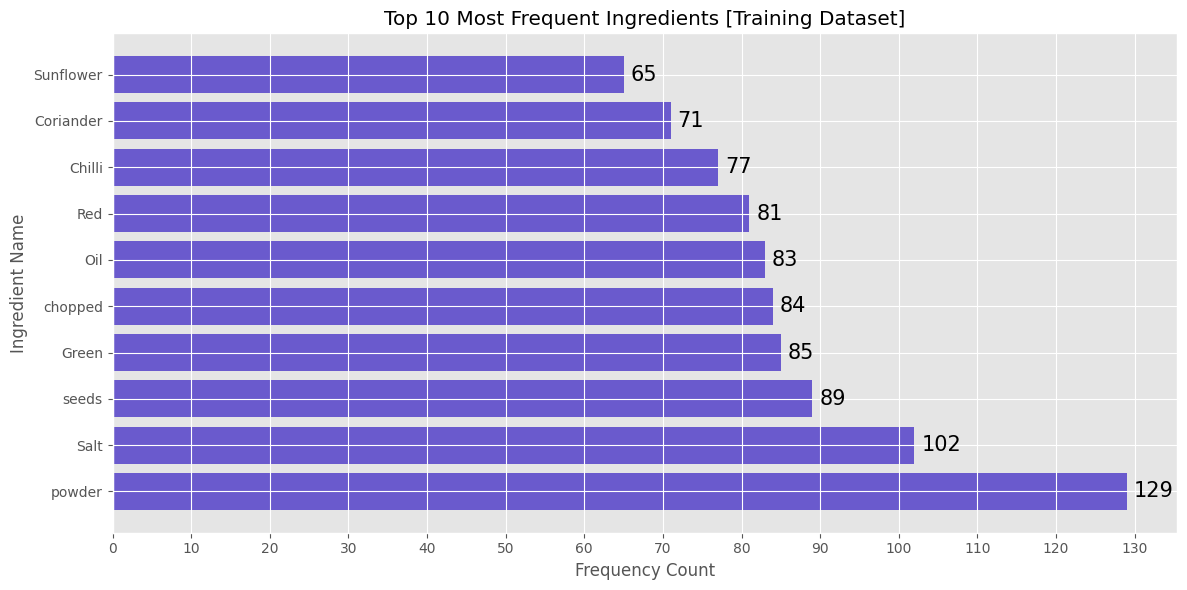

In [42]:
# Distribution of 1st Categorical Feature (Ingredients). The Top Frequent Ingredients in Training Data.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plot_top_items (
                title = "Top 10 Most Frequent Ingredients [Training Dataset]",
                xlabel= "Frequency Count",
                ylabel= "Ingredient Name",
                color= "slateblue",
                xticks_range= range(0,140,10),
                top_item_list= ingredient,
                pos_label= "Ingredient",
                dataset_name= dataset_name
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Categorical Feature (Ingredients)
log_progress ("(4.6) Visualizing: Top 10 Most Frequent Ingredients [Training Dataset]", "DEBUG")


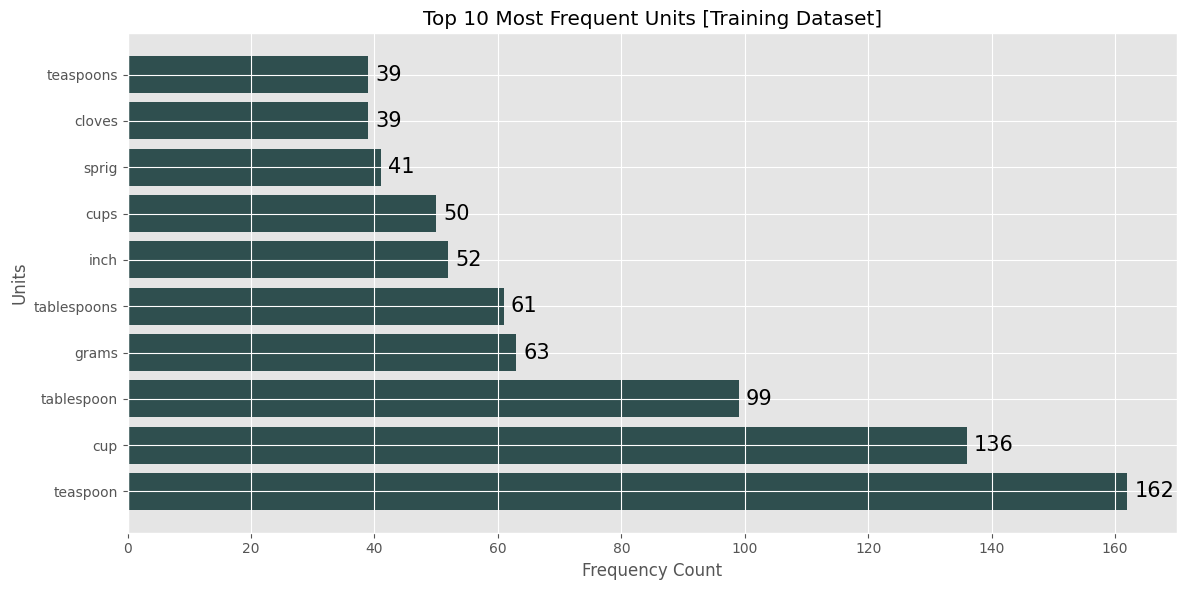

In [43]:
# Distribution of 2nd Categorical Feature (Units). The Top Frequent Units in Training Data.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plot_top_items (
                title = "Top 10 Most Frequent Units [Training Dataset]",
                xlabel= "Frequency Count",
                ylabel= "Units",
                color= "darkslategray",
                xticks_range= range(0,180,20),
                top_item_list= unit,
                pos_label= "Unit",
                dataset_name= dataset_name
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Categorical Feature (Units)
log_progress ("(4.7) Visualizing: Top 10 Most Frequent Units [Training Dataset]\n", "DEBUG")


### **Insights of the Training Dataset**
- **Unit Distribution**
    - **Spoon & Cup Based:** Spoon-based (teaspoon, tablespoon) and Cup-based (cup) measurements dominate the top-ranks.
    - **Stemming/Lemmatization:** Tokenization has treated (teaspoon, teaspoons), (cup, cups), (tablespoon, tablespoons) as different words / tokens.
---

- **Ingredient Distribution**
    - **Adjectives as Ingredients:** Words like (Green, Red, Chopped) are adjectives used to describe.
    - **Multi-Word:** "Red Chilli Powder" or "Chopped Coriander" or "Sunflower Seeds" have been broken into individual tokens.
    - **Regional Cuisine:** The Top ingredients suggest an Indian or South Asian influence in the recipe dataset.
---

- **Quantity Distribution**
    - **Low-value skew:** The training dataset is heavily skewed towards lower quantities (lower quantities frequently occur). Larger values are present in the bottom ten.
    - **Need for Regex or Advanced Library:** Needs robust handling of Quantities (1/2, 1/4) to specifically recognize fractions.

***

## **5** **Exploratory Recipe Data Analysis on Validation Dataset**


In [44]:
log_progress ("===================== Step 5 : Exploratory Recipe Data Analysis on Validation Dataset ====================", "INFO")

***

### **5.1 Validation Token Flattening and Parity Validation**

- **Sequence Flattening:** Flattened validation token and label sequences into a contiguous stream of `2,876 tokens and labels`.

- **Alignment Validation:** Confirmed a `1:1 token-label mapping`, ensuring structural integrity of the validation data for reliable model evaluation.

In [45]:
# Flatten the Tokens and Validate them 
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initialise the dataset_name
dataset_name = "Validation"

# Extraction and Validation of the tokens after using the Flattening Technique
try:
    validation_input, validation_pos = extract_and_validate_tokens(val_df, dataset_name)

except Exception as e:
    print(f"Error during extraction and validation: {e}")
    log_progress(f"(5.1) Error during extraction and validation: {e}", "ERROR")
    

Length Validation Successful.
Total tokens in Validation Set: 2,876
Total labels in Validation Set: 2,876
EDA Status: Validation set flattened and validated successfully.

First Ten Input Tokens: ['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']
First Ten POS Tokens: ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']


### **5.2 Validation Entity Categorization**

- **Entity Segregation:** Partitioned validation tokens into `ingredient, unit, and quantity` categories using the established categorization logic.

In [46]:
# Categorizing Labels into Respective List on the Validation Dataset
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    ingredient, unit, quantity = categorize_tokens(validation_input, validation_pos)

except Exception as e:
    print(f"Error during categorizing and validation: {e}")
    log_progress(f"(5.1) Error during categorizing and validation: {e}", "ERROR")

else:
    print(color.BOLD + "Validation and Categorizing into ['ingredient', 'quantity', 'unit'] Successful.\n" + color.END)
    log_progress(f"(5.1) Validation and Categorizing into ['ingredient', 'quantity', 'unit'] Successful.", "INFO") 

    # Display the First (10) Tags
    print(color.BOLD + "First Ten Ingredient Tokens: " + color.END + f"{ingredient[:10]}")
    print(color.BOLD + "First Ten Quantity Tokens: " + color.END + f"{quantity[:10]}")
    print(color.BOLD + "First Ten Unit Tokens: " + color.END + f"{unit[:10]}")
    

Validation and Categorizing into ['ingredient', 'quantity', 'unit'] Successful.

First Ten Ingredient Tokens: ['Ada', 'Milk', 'Sugar', 'Ghee', 'Cardamom', 'Powder', 'Elaichi', 'Carrot', 'Gajjar', 'chopped']
First Ten Quantity Tokens: ['1', '2', '3/4', '1/2', '1', '7', '2', '1/2', '6', '3']
First Ten Unit Tokens: ['cup', 'liter', 'tablespoon', 'teaspoon', 'cups', 'tablespoon', 'teaspoons', 'cup', 'teaspoon', 'inch']


In [47]:
print (color.BOLD + "The Top 10 Ingredients which are frequently seen in the Validation Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(ingredient, "Ingredient", dataset_name)):
    print (color.BOLD + f"Ingredient {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Ingredients which are frequently seen in the Validation Recipe Dataset:-

Ingredient 1: Powder ----> 54
Ingredient 2: Salt ----> 47
Ingredient 3: Oil ----> 39
Ingredient 4: Red ----> 39
Ingredient 5: Seeds ----> 36
Ingredient 6: Chilli ----> 36
Ingredient 7: Chopped ----> 31
Ingredient 8: Green ----> 30
Ingredient 9: Leaves ----> 29
Ingredient 10: Coriander ----> 27


In [48]:
print (color.BOLD + "The Top 10 Units which are frequently seen in the Validation Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(unit, "Unit", dataset_name)):
    print (color.BOLD + f"Unit {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Units which are frequently seen in the Validation Recipe Dataset:-

Unit 1: Teaspoon ----> 59
Unit 2: Cup ----> 57
Unit 3: Tablespoon ----> 32
Unit 4: Tablespoons ----> 32
Unit 5: Cups ----> 24
Unit 6: Sprig ----> 21
Unit 7: Inch ----> 20
Unit 8: Grams ----> 19
Unit 9: Teaspoons ----> 18
Unit 10: Cloves ----> 16


In [49]:
print (color.BOLD + "The Top 10 Quantity which are frequently seen in the Validation Recipe Dataset:-\n" + color.END)

for count, (item_name, frequency) in enumerate(get_top_frequent_items(quantity, "Quantity", dataset_name)):
    print (color.BOLD + f"Quantity {count + 1}: " + color.END + f"{item_name.capitalize()} ----> {frequency}")
    

The Top 10 Quantity which are frequently seen in the Validation Recipe Dataset:-

Quantity 1: 1 ----> 78
Quantity 2: 2 ----> 65
Quantity 3: 1/2 ----> 58
Quantity 4: 1/4 ----> 34
Quantity 5: 3 ----> 33
Quantity 6: 4 ----> 29
Quantity 7: 3/4 ----> 11
Quantity 8: 6 ----> 11
Quantity 9: 1-1/2 ----> 11
Quantity 10: 5 ----> 7


### **5.3 Graphical Distribution Analysis**

- **Distribution Consistency Validation:** Visualized token frequency distributions for the validation set, confirming alignment with training patterns and consistency in the underlying culinary taxonomy.

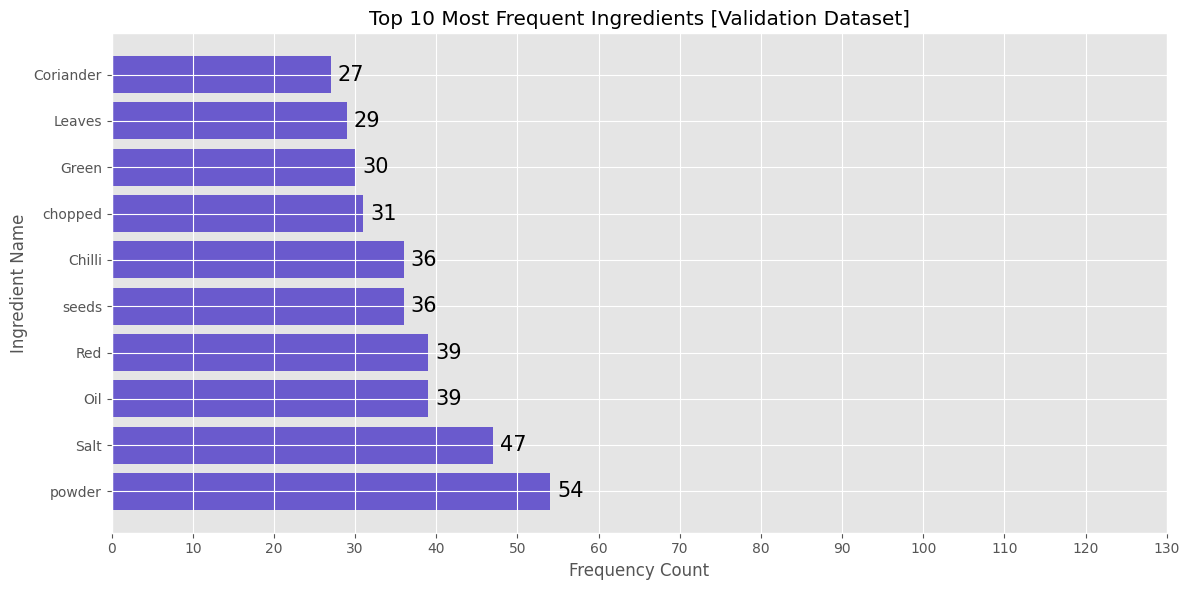

In [50]:
# Distribution of 1st Categorical Feature (Ingredients). The Top Frequent Validation in Training Data.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plot_top_items (
                title = "Top 10 Most Frequent Ingredients [Validation Dataset]",
                xlabel= "Frequency Count",
                ylabel= "Ingredient Name",
                color= "slateblue",
                xticks_range= range(0,140,10),
                top_item_list= ingredient,
                pos_label= "Ingredient",
                dataset_name= dataset_name
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Categorical Feature (Ingredients)
log_progress ("(5.2) Visualizing: Top 10 Most Frequent Ingredients [Validation Dataset]", "DEBUG")


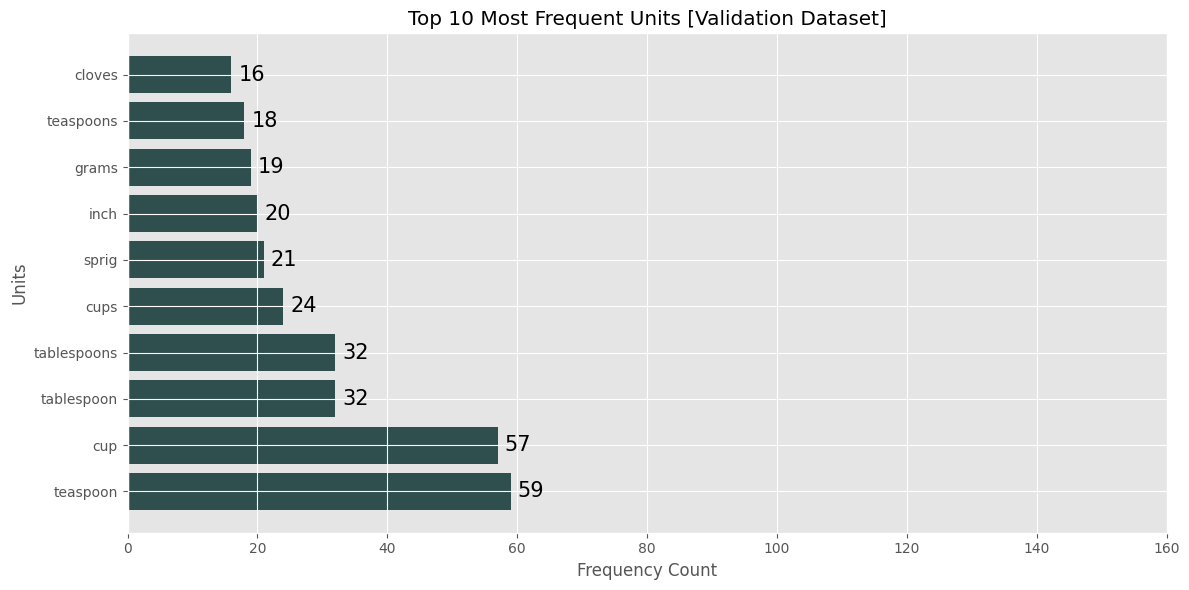

In [51]:
# Distribution of 2nd Categorical Feature (Units). The Top Frequent Units in Validation Data.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plot_top_items (
                title = "Top 10 Most Frequent Units [Validation Dataset]",
                xlabel= "Frequency Count",
                ylabel= "Units",
                color= "darkslategray",
                xticks_range= range(0,180,20),
                top_item_list= unit,
                pos_label= "Unit",
                dataset_name= dataset_name
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Categorical Feature (Ingredients)
log_progress ("(5.3) Visualizing: Top 10 Most Frequent Units [Validation Dataset]\n", "DEBUG")


---

## **6** **Feature Extraction For CRF Model**

In [52]:
log_progress("=============================== Step 6 : Feature Extraction For CRF Model ================================", "INFO")

---

### **6.1 Feature Engineering for CRF-Based Sequence Labeling**

Designed a comprehensive feature extraction pipeline to transform recipe tokens into structured representations for CRF training. This includes the definition of `domain-specific keyword sets (units and quantities)` and `regex-based patterns` to capture diverse numeric formats such as fractions, ranges, and decimals.

Implemented a `word2features` function to generate token-level feature dictionaries, incorporating linguistic attributes from `spaCy`, domain-aware indicators for `units and quantities`, and contextual signals from neighboring tokens. `Boundary markers (BOS/EOS)` were also integrated to preserve sequence structure, enabling the model to effectively learn token dependencies within recipe instructions.

---

#### **6.1.1 Keyword Lexicon and Pattern Engineering**

- **Domain Keyword Definition:** Defined comprehensive keyword sets for `units and quantities`, covering standard measurements (e.g., "cup", "gram"), shorthand forms (e.g., "tsp", "kg"), and linguistic representations (e.g., "half", "dozen") to support `rule-based feature extraction`.

- **Quantity Pattern Engineering:** Developed a `regex-based pattern` to capture diverse numeric formats, including integers, fractions (e.g., "1/2"), mixed fractions (e.g., "1-1/2"), ranges (e.g., "2-3"), and decimals (e.g., "1.5"), ensuring robust handling of real-world recipe data.

- **Pattern Validation:** Validated the regex against both synthetic test cases and actual dataset values to confirm accurate recognition of quantity expressions.

- **NLP Pipeline Initialization:** Loaded the `spaCy` language model (`en_core_web_sm`) to enable linguistic feature extraction for downstream sequence labeling tasks.

In [53]:
# Keywords: Unit Keywords are divided into [Root Form, Short Form] ---> Smart Keyword Extraction
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Unit --> Keywords
unit_keywords  = {# Volume: Liquid and Dry Volume Measurements [Note: Plural form of words will be taken care in 'word2features']
                  "spoon", "tablespoon", "teaspoon", "cup", "gill", "pint", 
                  "quart", "gallon", "liter", "milliliter",
                  
                  # Size: Qualitative Indicators
                  "large", "medium", "small",
                  
                  # Weight
                  "gram", "kilogram", "ounce", "pound",
                  
                  # Metric: Measuring Units
                  "centimeter", "millimeter", "meter", "inch", 

                  # Estimates: Subjective Unit (Non-Standard)
                  "pinch", "dash", "drop", "sprig", "clove", "bulb", "head", "bottle",
                  "bunch", "piece", "slice", "stick", "whole", "handful"}

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Unit --> Short Form
short_form_unit = {# Volume: Liquid and Dry Volume Measurements
                   "tsp", "tsps", "tbsp", "tbsps", "tbl", "tbs", "c",
                   "ml", "cl", "dl", "l", "pt", "qt", "gal", "pk", "fl", "cc",
    
                   # Weight
                   "mcg", "mg", "g", "gm", "gms", "kg", "lb", "lbs", "oz", "ozs",
    
                   # Metric: Measuring Units
                   "mm", "cm", "m", "in",
    
                   # Estimates: Non-Standard
                   "pkt", "pc", "pcs", "btl", "ea", "doz", "pkg", "pkgs"}

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Unit Keywords Defined
log_progress("(6.1.1.1) Unit Keywords and Short Forms: Defined Successfully", "DEBUG")


In [54]:
# Keywords: Quantity Keywords are divided into [Keywords, Key Patterns (Regex)] ---> Smart Keyword Extraction
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quantity --> Keywords
quantity_keywords = {# Number (Word-Form)
                     "one", "two", "three", "four", "five", 
                     "six", "seven", "eight", "nine", "ten",

                     # Ordinals
                     "first", "second", "third", "fourth", "fifth",
                     "sixth", "seventh", "eighth", "ninth", "tenth",

                     # Fractions, Quantiles, Specials
                     "dozen", "half", "quarter", "few", "several",
                     "many", "pair", "couple",
            
                     # Articles
                     "a", "an"}

# Logging: Quantity Keywords
log_progress("(6.1.1.2) Quantity Keywords: Defined Successfully", "DEBUG")   

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quantity --> Key Patterns [Integers, Fractions, Mixed Fractions, Ranges, Decimals]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. Integers         : To Match the Base Number (Integer ---> 0 to 9) (Example: "19", "200")     ---> \d+
# 2. Fractions        : To Match Simple Fractions (Fractions) (Example: 1/3, 2/4)                 ---> /\d+
# 3. Mixed Fractions  : To Match Complex Fractions (Complex Fractions) (Example: "1-1/2")         ---> [-\s]?\d+/\d+
# 4. Ranges           : To Match a String as a Range (Range of Numbers) (Example: "0-2", "3-5")   ---> -\d+
# 5. Decimals         : To Match Floating Point Numbers (Decimal Numbers) (Example: "1.5", "0.5") ---> \.\d+
# 6. Special Symbols  : To Handle Special Cases (Example: "+2/3")                                 ---> ^[+]?
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Starting and Ending Pattern
starting_pattern = "^"
ending_pattern = "$"

# Optional Prefix
optional_prefix = "[+]?"
optional_suffix = "?"

# Mandatory Digit (0 to 9)
mandatory_digits = "\d+"

# Decimal, Fractions, Negative Numbers
suffix = "(?:\.\d+|/\d+|-\d+|[-\s]\d+/\d+)"

# Final Regex Pattern Finder
quantity_pattern = re.compile(starting_pattern + optional_prefix + mandatory_digits + suffix + optional_suffix + ending_pattern)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Testing Scenarios: Based on Real-World Messy Data
test_scenarios = ["1", "10", "999", "2-3", "1.5", "1/2", "1-1/2", "+2/3"]
results = list() # Contains Results of the Outcomes

for index, test_case in enumerate(test_scenarios):
    print (color.BOLD + f"Scenario {index + 1} ({test_case}): " + color.END + f"{bool (quantity_pattern.match(test_case))}")

    # Adds (True or False) to the List
    results.append(bool (quantity_pattern.match(test_case)))
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quality Pattern: Validation Sucessful or Failed [Unit Test]
if all (results):
    print (color.BOLD + "\nQuantity Pattern Recognition [Unit Test]: " + color.END + "Successful." )
    log_progress ("(6.1.1.3) Quantity Pattern Recognition - Regex [Unit Test]: Successful.", "DEBUG")
else:
    print (color.BOLD + "\nQuantity Pattern Recognition [Unit Test]: " + color.END +  "Failed." + color.END)
    log_progress ("(6.1.1.3) Quantity Pattern Recognition - Regex [Unit Test]: Failed.", "WARNING")    



Scenario 1 (1): True
Scenario 2 (10): True
Scenario 3 (999): True
Scenario 4 (2-3): True
Scenario 5 (1.5): True
Scenario 6 (1/2): True
Scenario 7 (1-1/2): True
Scenario 8 (+2/3): True

Quantity Pattern Recognition [Unit Test]: Successful.


In [55]:
# Quality Pattern Checker: Validation on Real-World Recipe Dataset
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quality Pattern: Validation Sucessful or Failed [Recipe Data]
list_of_strings = []
list_of_numeric = []
list_of_misc    = []

for item in quantity:
    if item.strip().lower() in quantity_keywords:
        list_of_strings.append(item)
    elif bool (quantity_pattern.match(item)):
        list_of_numeric.append(item)
    else:
        list_of_misc.append(item)

log_progress ("(6.1.1.4) Quantity Pattern Recognition - Regex [Real-World Test]: Successful.", "INFO")
print (color.BOLD + "List of String Items [Present in Quantity Keywords]: " + color.END + f"{list_of_strings}"); print()
print (color.BOLD + "List of Miscellaneous Items [Not Present in Quantity Keywords]: " + color.END + f"{list_of_misc}"); print()
print (color.BOLD + "List of Passed Items [Quality Pattern Check ---> True] : " + color.END + f"{list_of_numeric}")


List of String Items [Present in Quantity Keywords]: ['a', 'few', 'a']

List of Miscellaneous Items [Not Present in Quantity Keywords]: ['is', 'to', 'for', 'pinch', 'cloves']

List of Passed Items [Quality Pattern Check ---> True] : ['1', '2', '3/4', '1/2', '1', '7', '2', '1/2', '6', '3', '1', '3', '1-1/12', '1/2', '2', '1', '1/2', '2', '2', '1', '1/2', '1', '3/4', '18', '2', '4', '3', '1/2', '2', '1', '1/2', '5', '1/4', '400', '200', '4', '3', '1/4', '350', '1', '2', '6', '1/2', '3', '1/4', '2', '2/3', '1-1/2', '1/4', '3/4', '3', '1/2', '9', '4', '1', '1/2', '2', '1', '1/2', '1', '4', '50', '2', '10', '3/4', '18', '2', '1/4', '1', '1/2', '10', '2', '1', '1/2', '1', '2', '1/2', '6', '4', '1/4', '2', '1/2', '3', '1', '3', '+1/3', '3/4', '1', '2', '250', '1/4', '1', '1/4', '2', '4', '1/2', '5', '1', '1/4', '2', '4', '1', '3', '2', '4', '1', '1/2', '1/4', '2', '6', '4', '1', '1-1/2', '1-1/2', '2', '4', '3', '2', '1', '8', '2', '1/4', '1/2', '325', '14', '2', '30', '500', '1', '3', '2', '1

In [56]:
# Load the spaCy model
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Small Light-weight english pipeline (Trained on Web-text)
    nlp = spacy.load("en_core_web_sm")

except OSError:
    print("Error loading spaCy model. Ensure it's downloaded.")
    log_progress ("(6.1.1.5) Error loading spaCy model. Ensure it's downloaded.", "ERROR")    

else:
    print("spaCy model loaded successfully.")
    log_progress ("(6.1.1.5) spaCy model loaded successfully.", "INFO")    


spaCy model loaded successfully.


#### **6.1.2 CRF Feature Engineering via `word2features`**

- **Feature Function Design:** Implemented a `word2features` function to extract `token-level features` for `CRF training`, transforming each token into a structured feature dictionary using its position within the sentence.

- **Core Linguistic Features:** Incorporated `lexical and syntactic attributes` derived from `spaCy`, including token normalization, lemma, part-of-speech tags, dependency relations, and shape features, along with indicators such as stopword presence, casing, punctuation, and character composition.

- **Domain-Aware Feature Augmentation:** Integrated `rule-based signals` using predefined unit and quantity keywords along with `regex-based pattern` matching to accurately identify numeric expressions, fractions, decimals, and measurement units within recipe text.

- **Contextual Feature Enrichment:** Captured `sequential dependencies` by including features from `neighboring tokens (previous and next)`, along with boundary indicators (BOS/EOS), enabling the model to leverage contextual cues for improved sequence labeling.

- **Efficient Feature Computation:** Optimized feature extraction by `minimizing redundant computations` (e.g., regex evaluation per token), ensuring scalability across the dataset.

In [57]:
# word2features: for processing each token in the sentence sent by using index i. (Feature Functions for CRF Model)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def word2features(sent, i, doc):
    """
    Docstring:
              Extracts features for a specific token in a recipe sentence.
              Generates a feature dictionary for a Conditional Random Field (CRF) Model.
              Captures the Lexical, Syntactic, and Contextual information for the token at index [i] within the sentence [sent].
    Parameters:
              sent (list of tuples): A list of tuples (word, label). A list represents a recipe sentence.
              i (int): The index of the current token being processed.
              doc (spacy.tokens.doc.Doc): A pre-processed spaCy Doc object. A container for accessing linguistic annotations.
    Returns:
              [features] Feature Functions (dict): A dictionary containing feature functions for CRF Model (Boolean and string features) for the token.
    """  
    
    # Capturing the Specific Word and Respective Token object
    word = sent[i]
    spaCy_token = doc[i] # Token Object [Provides access to linguistic annotations]

    # Saving Computation Resources: Run Regex only once (per token)
    regex_quantity_match = bool (quantity_pattern.match(word))

    # ---------------------------------------
    # ---------- (1) Core Features ----------
    # ---------------------------------------
    features = {
        "bias": 1.0,                      # Floating Point: Standard Convention (Continuous Number -- Baseline Probability) 
                                          # [Provides Model Flexibility ---> Enables Model to learn an intercept]
        
        "token": word.lower(),            # Lower Case: Current Word (Normalization -- Consistency, Generalization)
        "lemma": spaCy_token.lemma_.lower(), # Lemmatization: Break words to their base form [dictionary form] (Actual English Base Form of the Word)
        "pos_tag": spaCy_token.pos_,      # Part-of-Speech (POS) Tag: Universal (UPOS) in nature. Coarse-Grained (Example: NOUN, VERB, NUM)
        "tag": spaCy_token.tag_,          # Part-of-Speech (POS) Tag: Penn Treebank (PTB) tagset. Fine-Grained (Example: NNP, VBG)
        "dep": spaCy_token.dep_,          # Syntactic Dependency: Relationship between Tokens.
        "shape": spaCy_token.shape_,      # Shape of Token: The word shape – capitalization, punctuation, digits.
        "is_stop": spaCy_token.is_stop,   # Stop Words Detection: Is the token part of a stop list, i.e. the most common words of the language?
        
        "is_digit": word.isdigit(),       # Numeric Detection: Is the Token a Number? 
                                          # [Every character of the Token should be a number --> True, No Roman Numbers]
        
        "has_digit": any(char.isdigit()   # Single Number Detector: Does the Token contain at least one numeric value?
                      for char in word),  # Example: "ABC1" --->  True (Because 1 is a number)
        
        "has_alpha": any(char.isalpha()   # Letter/Alphabet Detector: Does the Token contain at least one letter/alphabet?
                      for char in word),  # Example: "1929c" ----> True (Because "c" is a letter/alphabet)
        
        "hyphenated": "-" in word,        # Hyphen (-) Detector: Does the String contain a Hyphen? (Example: "multi-word" ---> True)
        "slash_present": "/" in word,     # Slash (/) Detector: Does the String contain a Slash? (Example: "2/4" ---> True)
        
        "is_title": word.istitle(),       # First Letter (Uppercase) Detector: Does the first letter start with a capital letter? 
                                          # [Only the first letter can be Uppercase] [Number (present) --> False]

        "is_upper": word.isupper(),       # Uppercase Detector: Is the Token fully Uppercase? (Example: "OZ" ---> True)
        "is_punct": spaCy_token.is_punct  # Punctuation Detector: Is the Token a Punctuation? (Example: "!" ----> True)
    }

    # ------------------------------------------
    # - (2) Improved Quantity & Unit Detection -
    # ------------------------------------------
    features.update({
        # Quantity Detector: If Token is a Quantity (Check Presence in ---> Quantity Pattern or Quantity Keyword ---> If Yes ---> Boolean [True])
        "is_quantity": (word.strip().lower() in quantity_keywords) or (regex_quantity_match),

        # Unit Detector: If Token is a Unit [Measurement Unit] (Check Presence in Short Form and Keywords ---> If Yes ---> Boolean [True])
        "is_unit": (any(unit in spaCy_token.lemma_.strip().lower() for unit in unit_keywords) or (word.strip().lower() in short_form_unit)),

        # Numeric Pattern Detector: Is the Token a Integer, Fraction, Complex Fraction, Range, Floating Point Number etc..
        "is_numeric": regex_quantity_match,

        # Fraction Detector: Is the Token a Fraction or Complex Fraction?
        "is_fraction": (regex_quantity_match) and ("/" in word), 

        # Decimal Detector: Is the Token a Floating Point Number?
        "is_decimal": (regex_quantity_match) and ("." in word), 
        
        # Preceding Word: The Previous Token in the sentence (If available) (If not available -- Blank String) [Raw State of the Word]
        "preceding_word": sent[i-1] if i > 0 else "",
        
        # Following Word: The Next Token in the sentence (If available) (If not available -- Blank String) [Raw State of the Word]
        "following_word": sent[i+1] if i < len(sent) - 1 else ""
    })

    # -------------------------------
    # --- (3) Contextual Features ---
    # -------------------------------
    # A. Previous Token [Preceeding]
    # -------------------------------
    if i > 0:
        previous_word = sent[i-1]
        previous_regex_quantity_match = bool (quantity_pattern.match(previous_word))
        prev_is_quantity = (previous_word.strip().lower() in quantity_keywords) or (previous_regex_quantity_match)
        
        features.update({
            "prev_token": previous_word.lower(),      # Normalized (Lowercase form) of the previous token.
            "prev_is_quantity": prev_is_quantity,     # Previous Token: Quantity Detector (Is the previous word a Quantity?)
            "prev_is_digit": previous_word.isdigit(), # Boolean indicating if the previous token is a digit.
            "BOS": False})                            # Indicates if the token is at the Beginning of Sentence. --> False 
    else:
        # Missing Information ["prev_token", "prev_is_quantity", "prev_is_digit"] -- CRF Models handle (treated as inactive)
        features.update({"BOS" : True})               # Indicates if the token is at the Beginning of Sentence --> True
        
    # -------------------------------
    # B. Next Token [Following]
    # -------------------------------
    if i < len(sent) - 1:
        next_word = sent[i+1]
        next_word_spaCy = doc[i+1]
        next_is_unit = (any(unit in next_word_spaCy.lemma_.strip().lower() for unit in unit_keywords) or (next_word.strip().lower() in short_form_unit))
        next_regex_quantity_match = bool (quantity_pattern.match(next_word))
        next_is_quantity = (next_word.strip().lower() in quantity_keywords) or (next_regex_quantity_match)
        next_is_ingredient = not (next_is_quantity or next_is_unit)

        features.update({
            "next_token": next_word.lower(),          # Normalized (Lowercase form) of the next token.
            "next_is_unit": next_is_unit,             # Next Token: Unit Detector (Is the next token a Unit?)
            "next_is_ingredient": next_is_ingredient, # Boolean indicating if the next token is not a unit or quantity.
            "EOS": False})                            # Indicates if the token is at the End of the Sentence. --> False 
    else:
        # Missing Information ["next_token", "next_is_unit", "next_is_ingredient"] -- CRF Models handle (treated as inactive)
        features.update({"EOS" : True})               # Indicates if the token is at the End of the Sentence. --> True

    return features
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Progress [word2features]
log_progress ("(6.1.2.1) word2features --> Defined Feature Functions for CRF Model.", "DEBUG")


---

### **6.2 Preparation of Recipe-Level Features**

Constructed `sentence-level feature representations by applying token-level feature extraction` across entire recipe sequences. This step transforms each recipe into a structured sequence of feature dictionaries, enabling the CRF model to learn from both individual token attributes and their contextual relationships.

---

#### **6.2.1 Sentence-Level Feature Extraction via sent2features**

- **Feature Aggregation:** Implemented a `sent2features` function to generate feature dictionaries for all tokens within a sentence by applying the `word2features` function iteratively.

- **Efficient NLP Processing:** Processed each sentence through the `spaCy` pipeline once, enabling efficient extraction of linguistic features for all tokens in the sequence.

In [58]:
# sent2features: Works on each token in the sentence and correctly generate dictionaries for features
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def sent2features(sent):
    """
    Docstring:
               Performs features extraction for an entire recipe sentence.
               Pre-processes the sentence through spaCy NLP pipeline. [Per Sentence Once -->> Computational Efficiency]
               Iterates through each token to build a sequence-level feature set 
               Takes a sentence and extracts features for every token.
    Parameters:
               sent (list of lists): A list of strings, where each string is a token in a recipe sentence.
    Returns:   
               [list]:- List of dict: A list of feature dictionaries. (One dictionary for each token in the sentence)
    """
    # Joining - List of Words ----> Sentence
    sentence_raw = " ".join(sent)

    # Doc ---> Send Raw Setence to spaCy's NLP Pipeline (Acts as a container for accessing linguistic annotations)
    doc = nlp(sentence_raw)

    # Return features for every token
    return [word2features(sent, i, doc) for i in range(len(sent))]
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Progress [sent2features]
log_progress("(6.1.2.2) sent2features --> Generated sentence-level feature wrapper.", "DEBUG")


---

### **6.3 Dataset Transformation for CRF Training**

Transformed the training and validation datasets into CRF-compatible formats by generating feature representations (`X_train_features`, `X_val_features`) and aligning corresponding label sequences (`y_train_labels`, `y_val_labels`). Verified feature-label consistency across both splits, ensuring correct sequence alignment prior to model training.

---

#### **6.3.1 Dataset-Level Feature Transformation**

- **Feature Transformation:** Converted training and validation recipe sequences into CRF-compatible feature representations by applying sentence-level feature extraction across all observations, resulting in `X_train_features` and `X_val_features`.

In [59]:
# Converting input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
# X_train ---> Input Features for Training Set   (Raw Input Tokens)
# X_val   ---> Input Features for Validation Set (Raw Input Tokens)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# X_train_features ---> A List of Feature Dictionaries to Train the CRF Model [Training]
X_train_features = [sent2features(sentence) for sentence in X_train]

# X_val_features   ---> A List of Feature Dictionaries to Validate the CRF Model [Validation]
X_val_features   = [sent2features(sentence) for sentence in X_val]

# Logging: Feature Transformation
log_progress("(6.1.3.1) Feature Transformation --> Generated `X_train_features`, `X_val_features`.", "INFO")


#### **6.3.2 Label Preparation for Model Training**

- **Label Structuring:** Prepared training and validation label sequences in list format (`y_train_labels`, `y_val_labels`) to align with the feature representations for CRF model training and evaluation.

In [60]:
# Converting labels into list as y_train_labels and y_val_labels
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# y_train_labels ---> Ground Truth Labels for Training Set   
y_train_labels = [labels for labels in y_train]

# y_val_labels   ---> Ground Truth Labels for Validation Set 
y_val_labels   = [labels for labels in y_val]

# Logging: Label Extraction
log_progress("(6.1.3.2) Label Extraction --> Generated `y_train_labels`, `y_val_labels`.", "INFO")


#### **6.3.3 Feature-Label Alignment Verification**

- **Integrity Check:** Verified that the number of feature sequences matches the corresponding label sequences for both `training (196)` and `validation (84)` datasets, ensuring proper alignment for model training.

In [61]:
# print the length of train features and labels
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "Training Features Length: " + color.END + f"{len(X_train_features)}")
print (color.BOLD + "Training Labels Length: " + color.END + f"{len(y_train_labels)}")


Training Features Length: 196
Training Labels Length: 196


In [62]:
# print the length of validation features and labels
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "Validation Features Length: " + color.END + f"{len(X_val_features)}")
print (color.BOLD + "Validation Labels Length: " + color.END + f"{len(y_val_labels)}")


Validation Features Length: 84
Validation Labels Length: 84


In [63]:
# Final Verification Step: Ensures 1 to 1 Mapping
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if (len(X_train_features) == len(y_train_labels)) and (len(X_val_features) == len(y_val_labels)):
    print (color.BOLD + "Verification Successful: " + color.END + "Feature and Label counts match perfectly.")
    log_progress("(6.1.3.3) Data Integrity Check --> Verification Successful: Feature and Label counts match perfectly.", "INFO")
else:
    print ("Verification Failed: Feature and Label counts do not match.")

    # Training Verification: Independent
    if (len(X_train_features) != len(y_train_labels)):
        print (f"Training: {len(X_train_features)} != {len(y_train_labels)}")

    # Validation Verification: Independent
    if (len(X_val_features) != len(y_val_labels)):
        print (f"Validation: {len(X_val_features)} != {len(y_val_labels)}")
        
    log_progress("(6.1.3.3) Data Integrity Check --> Verification Failed: Feature and Label counts do not match.", "WARNING")  


Verification Successful: Feature and Label counts match perfectly.


---

### **6.4 Applying Weights to Feature Sets**

Addressed `class imbalance` within the training data by deriving `inverse frequency-based label weights` and integrating them into the feature representation pipeline. This involved analyzing label distributions, computing weighted importance for each entity class, and augmenting token-level feature dictionaries with these weights. The resulting weighted feature sets enable the CRF model to better learn underrepresented entities while mitigating bias toward dominant classes.

---

#### **6.4.1 Flattening Training Labels**

- **Label Flattening:** Converted nested training label sequences into a single contiguous list (`y_train_flat`) to enable token-level evaluation and analysis.

In [64]:
# Flattening the labels in y_train_labels ----> y_train_flat (y_train_labels --> Used for Consistency)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Let's understand the "Docstring"
print(flatten_list.__doc__)

# Applying the pre-defined function
y_train_flat = flatten_list (y_train_labels)



    Docstring: 
               Converts a nested list (list of lists) into a single flat list.
    Parameters:
               Nested List (nested_list): Takes a list either (input_tokens or pos_tokens) and flattens it.
    Returns:
               A Single Flattened List.
    Example:
               flatten_list(nested_list)
    


#### **6.4.2 Label Distribution Analysis**

- **Label Frequency Analysis:** Computed the distribution of training labels, identifying `5,323 Ingredient, 980 Quantity, and 811 Unit tokens` across a `total of 7,114 samples`.

- **Class Imbalance Insight:** Observed a `significant dominance of Ingredient labels`, indicating a potential class imbalance that may influence model learning.

In [65]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Frequency of each unique label present in y_train_flat
label_counts = dict(Counter(y_train_flat))

# Summation of all Values --> Total Number of Tokens (Combined from all labels)
total_samples = sum(label_counts.values())

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quick Distribution Analysis [Based on Frequency of Target Variable --> POS Labels]
print ("-------------------------------")
print (color.BOLD + "Quick Distribution Analysis" + color.END)
print ("-------------------------------")

# Quick Note: `.capitalize()` has been used for the purpose of displaying [presentation]
for index, (label, count) in enumerate(label_counts.items()):
    print (color.BOLD + f"Label {(index + 1)}: " + color.END + f"{label.capitalize()} ----> {count:,}")

print (color.BOLD + "\nTotal Number of Samples: " + color.END + f"{total_samples:,}")


-------------------------------
Quick Distribution Analysis
-------------------------------
Label 1: Quantity ----> 980
Label 2: Unit ----> 811
Label 3: Ingredient ----> 5,323

Total Number of Samples: 7,114


#### **6.4.3 Class Weight Computation via Inverse Frequency**

- **Imbalance Handling:** Computed class weights using an `inverse frequency approach`, assigning higher weights to underrepresented labels `(Quantity: 7.259, Unit: 8.772)` and lower weight to the dominant Ingredient class.

- **Controlled Penalization:** Applied an additional penalty factor to the `Ingredient label (final weight: 0.668)` to reduce model bias toward the majority class and encourage better learning of minority entities.

In [66]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logic: 
#        Rarer Labels (Smaller Count) ----> Higher Weightage
#        Common Labels (Higher Count) ----> Lower Weightage
# Example:
#         Total Number of Samples: 7114
#         Unit (Smaller Count) : 811 Count ----> Inverse Frequency ----> 7114 / 811 ----> 8.77 Weight [Rare, Higher Weight]
#         Quantity (Smaller Count) : 980 Count ----> Inverse Frequency ----> 7114 / 980 ----> 7.26 Weight [Rare, Higher Weight]
#         Ingredient (Higher Count) : 5323 Count ----> Inverse Frequency ----> 7114 / 5323 ----> 1.34 Weight [Common, Lower Weight]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initializing a dictionary to store label weights
weight_dict = dict()

# Penalise `Ingredient` label [Penalty Factor --> 0.5] 
# Tells the model `Ingredient` appears more frequently, but don't blindly preedict it [Pay Attention to Rare Labels like `Quanity`, `Unit`]
penalty_for_ingredient = 0.5

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Base Weights: Using Inverse Frequency
for label, count in label_counts.items():
    # To Avoid ZeroDivisionError
    if count > 0:
        # Calculating: Inverse Frequency [Base Weight]
        current_weight = total_samples / count 
    
        # Applying Penaly to `Ingredient`
        if label.lower() == "ingredient":
           current_weight = current_weight * penalty_for_ingredient

        # Assigning Weight
        weight_dict[label] = current_weight
    else:
        # Label with a count of zero gets a weight of zero [Edge Case] [No contribution to Training]
        weight_dict[label] = 0

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Quick Data Driven Weight Dictionary
print ("--------------------------------------------")
print (color.BOLD + "Quick Data Driven Weight Dictionary" + color.END)
print ("--------------------------------------------")

# Quick Note: `.capitalize()` has been used for the purpose of displaying [presentation]
for index, (label, weight) in enumerate(weight_dict.items()):
    boosted_or_penalized = "(PENALIZED)" if label.lower() == "ingredient" else "(BOOSTED)"
    print (color.BOLD + f"Label {(index + 1)}: " + color.END + f"{label.capitalize()} ----> {weight:.3f} " + color.BOLD + boosted_or_penalized + color.END)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Base Class Weights Computed
log_progress ("(6.1.3.4) Computing Base Weights --> Inverse Frequency Method implemented for Class Imbalance.", "INFO")


--------------------------------------------
Quick Data Driven Weight Dictionary
--------------------------------------------
Label 1: Quantity ----> 7.259 (BOOSTED)
Label 2: Unit ----> 8.772 (BOOSTED)
Label 3: Ingredient ----> 0.668 (PENALIZED)


#### **6.4.4 Feature Augmentation with Class Weights**

- **Weighted Feature Integration:** Defined a function `(extract_features_with_class_weights)` to incorporate class weights into token-level feature dictionaries, enabling the model to account for label imbalance during training.

- **Sequence-Level Consistency:** Applied weight mapping across all tokens in `both training and validation sequences`, ensuring each feature representation carries its corresponding label importance.

In [67]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def extract_features_with_class_weights(X_input_tokens: list, y_labels: list, class_weight_dict: dict):
    """
    Docstring:
              Adding the Calculated Class Weight of the Respective Token into the existing Feature Dictionary.
    Parameters:
              X_input_tokens (list): Nested list of Feature Dictionaries to Train the CRF Model. (Example: `X_train_features`)
              y_labels (list): Nested list of Ground Truth Labels. (Example: `y_train_labels`)
              class_weight_dict (dict): Contains Inverse Frequency Weights for the labels. 
                                        [Smaller Count --> Higher Weight] [Higher Count ---> Lower Weight]
    Returns:
              [updated_features] Updated Feature Functions (list): 
              A list containing feature functions for CRF Model for the token [with the label weights updated].
    """
    # Initializing a list for Updated Features
    updated_features = list()
    
    # Sentence Level: Loop through each sentence
    for sentence_features, sentence_labels in zip(X_input_tokens, y_labels):
        
        # Initializing a List [Stores Weights @ Sentence Level]
        sentence_with_weights = list()
        
        # Word Level: Loop through each token (word) in the sentence
        for word_features, word_labels in zip(sentence_features, sentence_labels):

            # Avoid Overwriting Original: Creating a Copy
            copy_features = word_features.copy()

            # Checking Lowercase to match `class_weight_dict`, Edge Case: Unknown label appears default to `1`
            class_weight = class_weight_dict.get(word_labels.lower(), 1)

            # Updating weights into the feature dictionary
            copy_features ["y_weight_label"] = class_weight

            # Updating [Specific Sentence] -- Add the Updated Token/Word
            sentence_with_weights.append(copy_features)

        # Update the Completed Sentence to the Final Features
        updated_features.append(sentence_with_weights)

    # Returns: Features with Weights Updated
    return updated_features

# Logging: Feature Injection --> Function Defined
log_progress ("(6.1.3.5) Function Defined for Weight Injection: `extract_features_with_class_weights`", "DEBUG")  


#### **6.4.5 Weighted Feature Transformation**

- **Execution:** Applied class-weighted feature extraction to both training and validation datasets, generating `X_train_weighted_features` and `X_val_weighted_features` for imbalance-aware model training.

In [68]:
# Apply manually computed class weights [To handle class imbalance]
# The Inverse Frequency Weights of the Ground Truth Labels are mapped to the Training/Validation Set.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Training Set
X_train_weighted_features = extract_features_with_class_weights(X_train_features, y_train_labels, weight_dict)

# Validation Set
X_val_weighted_features   = extract_features_with_class_weights(X_val_features, y_val_labels, weight_dict)

# Logging: Feature Injection --> Function Applied
log_progress ("(6.1.3.6) The Inverse Frequency Weights of the Ground Truth Labels are mapped to the Training/Validation Set.\n", "INFO") 


---

## **7 Model Building and Training**

Implemented and trained a Conditional Random Field (CRF) model using engineered, context-rich feature representations with class imbalance handling. Evaluated model performance on the training dataset and persisted the trained model for reuse.

In [69]:
log_progress("================================== Step 7 : Model Building and Training ==================================", "INFO")

---

### **7.1 CRF Model Initialization and Training**

- **Model Training:** Trained a `Conditional Random Field (CRF) model using L-BFGS optimization` on the engineered feature space, incorporating class-weighted representations to address label imbalance.

- **Regularization Strategy:** Configured `c1=0.5` and `c2=1.0` to balance feature sparsity and generalization, preventing overfitting to dominant patterns such as Ingredient labels.

- **Transition Modeling:** Enabled `all_possible_transitions` to allow the model to learn a richer set of label transitions, improving its ability to capture sequence dependencies.

- **Training Context:** Model trained on `196 recipe sequences (7,114 tokens)`, leveraging both linguistic features and domain-specific signals for robust sequence labeling.

In [70]:
# Initializing the CRF Model with specific hyperparameters & Training it with the weighted training data.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1) Initializing a CRF model
crf = sklearn_crfsuite.CRF(
            algorithm= "lbfgs",             # Optimized Algorithm: Approximates BFGS Algorithm (Highly Efficient) 
            c1= 0.5,                        # L1 Regularization: Helps in Feature Selection
            c2= 1.0,                        # L2 Regularization: Prevents Overfitting
            max_iterations=100,             # Number of Covergence Attempts: Trade-off between `Solution Quality` and `Computation Resource (Time taken)`
            all_possible_transitions=True  # Learns all label-to-label pairs
         )
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2) Training the CRF model with the weighted training data
try:
    print(color.BOLD + "Training Started: Number of Recipes ---> " + color.END + f"{len(X_train_weighted_features)} Recipes.")
    print(color.BOLD + "Training Started: Number of Tokens ---> " + color.END + f"{sum (len(sentence) for sentence in X_train_weighted_features):,} Tokens.")
    print("-----------------------------------------------------")
    print(color.BOLD + "Loading training data to CRFsuite" + color.END)
    print("-----------------------------------------------------")
    print(color.BOLD + "Algorithm: " + color.END + "L-BFGS optimization")
    print(color.BOLD + "c1: " + color.END + "0.500000")
    print(color.BOLD + "c2: " + color.END + "1.000000")
    print(color.BOLD + "max_iterations: " + color.END + "100")
    print(color.BOLD + "all_possible_transitions: " + color.END + "True")
    crf.fit(X_train_weighted_features, y_train_labels)
    print("-----------------------------------------------------")
    
    log_progress("(7.1) Conditional Random Field (CRF) Model initialized and trained successfully.", "INFO")
    
    print(color.BOLD + "Training Completed: " + color.END + "Successfully.")

except Exception as e:
    print (f"Conditional Random Field (CRF) Model failed: {e}")
    log_progress(f"(7.1) Conditional Random Field (CRF) Model failed: {e}", "ERROR")
    

Training Started: Number of Recipes ---> 196 Recipes.
Training Started: Number of Tokens ---> 7,114 Tokens.
-----------------------------------------------------
Loading training data to CRFsuite
-----------------------------------------------------
Algorithm: L-BFGS optimization
c1: 0.500000
c2: 1.000000
max_iterations: 100
all_possible_transitions: True
-----------------------------------------------------
Training Completed: Successfully.


### **7.2 Training Set Evaluation**

- **Performance Metrics:** Achieved perfect `precision, recall, and F1-score (1.00)` across all entity classes `(Ingredient, Quantity, Unit)`, with an `overall accuracy of 100%` on the training dataset.

- **Confusion Matrix Analysis:** Predictions are nearly perfectly aligned with true labels, with only `minor misclassifications` observed (e.g., a few Quantity tokens predicted as Unit), indicating strong learning of token-label mappings.

- **Model Behavior Insight:** The `near-perfect performance` suggests that the model has effectively captured training patterns; however, this may also indicate potential overfitting, making validation performance critical for assessing generalization.

-------------------------------------------------------------------
Classification Report: Training Dataset [Purpose ---> Evaluation]
-------------------------------------------------------------------
              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00      5323
    quantity       1.00      1.00      1.00       980
        unit       1.00      1.00      1.00       811

    accuracy                           1.00      7114
   macro avg       1.00      1.00      1.00      7114
weighted avg       1.00      1.00      1.00      7114

-------------------------------------------------------------------


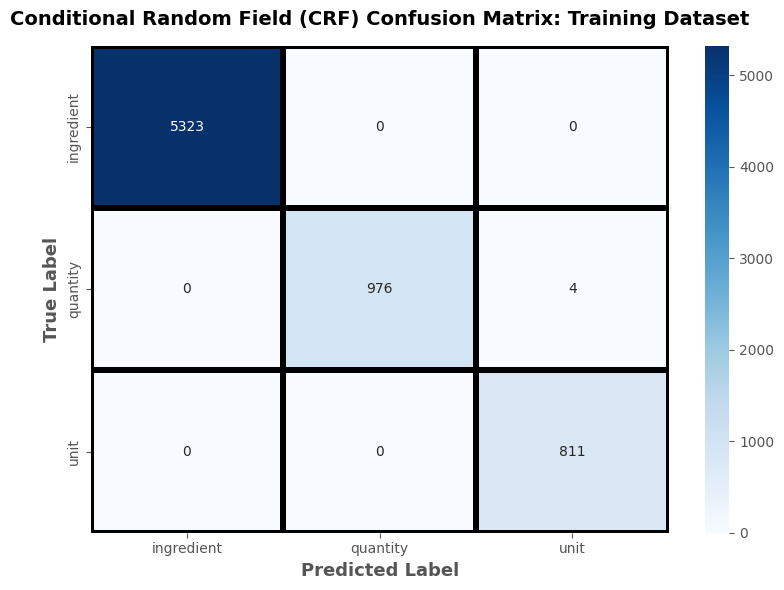

Training Evaluation Completed: Successfully.
Confusion Matrix [Training Dataset]: Created Successfully.


In [71]:
# Evaluating the CRF Model on the Training Dataset
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Make Predictions of the Training Dataset
y_train_predictions = crf.predict(X_train_weighted_features)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Classification Report: Training Dataset [Purpose ---> Evaluation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# y_train_labels -----> Actual Labels
# y_train_predictions -----> Predicted Labels
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print ("-------------------------------------------------------------------")
print (color.BOLD + "Classification Report: Training Dataset [Purpose ---> Evaluation]" + color.END)
print ("-------------------------------------------------------------------")
training_classification_report = flat_classification_report (y_train_labels, y_train_predictions)
print (training_classification_report)
print ("-------------------------------------------------------------------")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Confusion Matrix: Training Datset [Evaluating the Performance on Training Dataset]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Applying the pre-defined function [Flatten the Nested List]
y_train_flat = flatten_list (y_train_labels)
y_train_predictions_flat = flatten_list (y_train_predictions)

# Unique Labels: Identifying the labels [For Consistency - Across Training, Testing and Validation Phase]
unique_labels = sorted (list (set(y_train_flat)))

# Confusion Matrix: Actual Labels vs Predicted Labels
cm_training = confusion_matrix(y_true= y_train_flat, y_pred= y_train_predictions_flat, labels= unique_labels)

# Visualizing: Confusion Matrix (Heatmap) [Training Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(
            data= cm_training, # Dataset: Training Data
            annot= True, # Annotations: On
            fmt= "d", # Format: Decimal
            cmap= "Blues", # Color: Colormap for Plot
            xticklabels= unique_labels, # Set Labels: X-Axis
            yticklabels= unique_labels, # Set Labels: Y-Axis
            linewidths= 3, # Line Width: Thickness of the Separating Line
            linecolor= "black" # Color of the Separating Line
)
plt.title("Conditional Random Field (CRF) Confusion Matrix: Training Dataset", fontsize= 14, fontweight= "bold", pad= 15)
plt.xlabel("Predicted Label", fontsize= 13, fontweight= "bold")
plt.ylabel("True Label", fontsize= 13, fontweight= "bold")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Progress
print(color.BOLD + "Training Evaluation Completed: " + color.END + "Successfully.")
print(color.BOLD + "Confusion Matrix [Training Dataset]: " + color.END + "Created Successfully.")
log_progress ("(7.2) Training Evaluation: Classification Report and Confusion Matrix Created Successfully.", "INFO")


### **7.3 Model Persistence**

- **Model Saving:** Serialized the trained CRF model using `joblib`, storing it as `crf_model.pkl` (`~0.04 MB`) for efficient reuse without retraining.

In [72]:
# Saving the CRF model [dump the model using joblib as crf_model.pkl]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# File Name: To be saved as
model_file_name = "crf_model.pkl"

try:
    # Enables: Efficient Reuse (Without Re-training)
    joblib.dump(crf, model_file_name)
except Exception as e:
    print (color.BOLD + "Model Saving Failed: " + color.END + f"{e}")
    log_progress (f"(7.3) Model Saving Failed: {e}\n", "INFO")
else:
    log_progress (f"(7.3) Model Persistence: Trained CRF Model saved Successfully as `{model_file_name}`\n", "INFO")
    print ("-------------------------------------------------------")
    print (color.BOLD + "Conditional Random Field (CRF) Model - Metadata Report" + color.END)
    print ("-------------------------------------------------------")
    print(color.BOLD + "CRF Model Status: " + color.END + "Saved Successfully")
    print(color.BOLD + "File Name: " + color.END + f"{model_file_name}")
    print(color.BOLD + "File Size (In MB): " + color.END + f"{os.path.getsize(model_file_name) / (1024 * 1024):.3f} MB")
    print ("-------------------------------------------------------")
    

-------------------------------------------------------
Conditional Random Field (CRF) Model - Metadata Report
-------------------------------------------------------
CRF Model Status: Saved Successfully
File Name: crf_model.pkl
File Size (In MB): 0.037 MB
-------------------------------------------------------


---

## **8 Prediction and Model Evaluation**

Evaluated the trained CRF model on the validation dataset, assessing its ability to generalize using classification metrics and confusion matrix analysis.

In [73]:
log_progress("================================ Step 8 : Prediction and Model Evaluation ================================", "INFO")

---

### **8.1 Validation Set Evaluation**

- **Performance Metrics:** Achieved near-perfect precision, recall, and F1-scores across all entity classes, with overall accuracy of 100% on the validation dataset.

- **Confusion Matrix Analysis:** Predictions are highly consistent with true labels, with only minimal misclassifications observed between Quantity and Unit classes, indicating strong discrimination between entity types.

- **Generalization Insight:** The model maintains high performance on unseen validation data, suggesting effective generalization and minimal overfitting despite perfect training accuracy.

- **Model Robustness:** Strong results highlight the effectiveness of feature engineering, contextual signals, and class-weighting strategies in capturing structured patterns within recipe data.

In [74]:
# Loading the Pre-Trained CRF Model [Goal--> CRF Model is loaded to make predictions on the Validation Dataset]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initializing: Active CRF model to None
active_crf_model = None

try:
    # First Attempt: Loading Pre-Trained CRF Model
    active_crf_model = joblib.load(model_file_name)

except Exception as e:
    # Problem Loading Pre-Trained Model
    print(f"{color.BOLD}Pre-Trained CRF Model Loading Failed: {color.END}{e}")
    log_progress(f"(8.1) Pre-Trained CRF Model Loading Failed: {e}", "ERROR")

    try:
        # Second Attempt: Loading In-memory Model (Falling Back)
        print(f"{color.BOLD}In-memory CRF Model{color.END}: Switching Back...")

        # Active Model: Verifies if the In-memory Model is capable of making predictions
        if hasattr(crf, "classes_"):
            active_crf_model = crf
            print(f"{color.BOLD}In-memory CRF Model{color.END}: Successfully Verified.")

    except Exception as e:
        print(f"{color.BOLD}Critical Error [No Active Models]:{color.END} {e}")
        log_progress(f"(8.1) Critical Error [No Active Models]: {e}", "ERROR")

else:
    print(f"{color.BOLD}Pre-Trained CRF Model:{color.END} Loaded Successfully.")
    log_progress("(8.1) Pre-Trained CRF Model: Loaded Successfully.", "INFO")
    

Pre-Trained CRF Model: Loaded Successfully.


-------------------------------------------------------------------
Classification Report: Validation Dataset [Purpose ---> Evaluation]
-------------------------------------------------------------------
              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00      2107
    quantity       1.00      1.00      1.00       411
        unit       0.99      1.00      1.00       358

    accuracy                           1.00      2876
   macro avg       1.00      1.00      1.00      2876
weighted avg       1.00      1.00      1.00      2876

-------------------------------------------------------------------


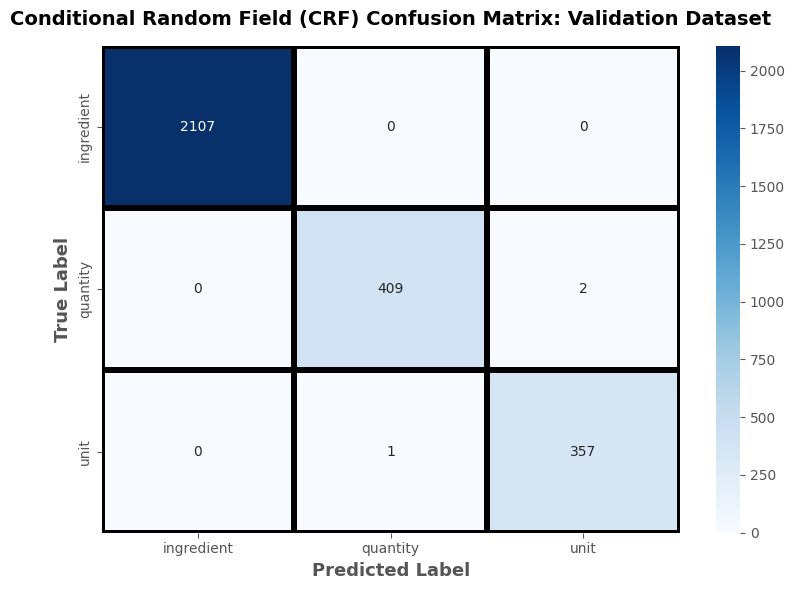

Validation Evaluation Completed: Successfully.
Confusion Matrix [Validation Dataset]: Created Successfully.


In [75]:
# CRF Model to make predictions on the Validation Dataset
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if active_crf_model is not None:
    # Make Predictions of the Validation Dataset
    y_val_predictions = active_crf_model.predict(X_val_weighted_features)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Classification Report: Validation Dataset [Purpose ---> Evaluation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# y_val_labels -----> Actual Labels
# y_val_predictions -----> Predicted Labels
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    print ("-------------------------------------------------------------------")
    print (color.BOLD + "Classification Report: Validation Dataset [Purpose ---> Evaluation]" + color.END)
    print ("-------------------------------------------------------------------")
    validation_classification_report = flat_classification_report (y_val_labels, y_val_predictions)
    print (validation_classification_report)
    print ("-------------------------------------------------------------------")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Confusion Matrix: Validation Datset [Evaluating the Performance on Validation Dataset]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Applying the pre-defined function [Flatten the Nested List]
    y_val_flat = flatten_list (y_val_labels)
    y_val_predictions_flat = flatten_list (y_val_predictions)

    # Unique Labels: Identifying the labels [For Consistency - Across Training, Testing and Validation Phase]
    unique_labels = sorted (list (set(y_val_flat)))

    # Confusion Matrix: Actual Labels vs Predicted Labels
    cm_validation = confusion_matrix(y_true= y_val_flat, y_pred= y_val_predictions_flat, labels= unique_labels)

    # Visualizing: Confusion Matrix (Heatmap) [Training Dataset
    plt.figure(figsize=(8, 6))
    sns.heatmap(
                data= cm_validation, # Dataset: Validation Data
                annot= True, # Annotations: On
                fmt= "d", # Format: Decimal
                cmap= "Blues", # Color: Colormap for Plot
                xticklabels= unique_labels, # Set Labels: X-Axis
                yticklabels= unique_labels, # Set Labels: Y-Axis
                linewidths= 3, # Line Width: Thickness of the Separating Line
                linecolor= "black" # Color of the Separating Line
)
    plt.title("Conditional Random Field (CRF) Confusion Matrix: Validation Dataset", fontsize= 14, fontweight= "bold", pad= 15)
    plt.xlabel("Predicted Label", fontsize= 13, fontweight= "bold")
    plt.ylabel("True Label", fontsize= 13, fontweight= "bold")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Progress
    print(color.BOLD + "Validation Evaluation Completed: " + color.END + "Successfully.")
    print(color.BOLD + "Confusion Matrix [Validation Dataset]: " + color.END + "Created Successfully.")
    log_progress ("(8.2) Validation Evaluation: Classification Report and Confusion Matrix Created Successfully.\n", "INFO")

else:
    print(f"{color.BOLD}Critical Failure:{color.END} Pipeline Halted.")
    print(f"{color.BOLD}Reason for Failure:{color.END} No CRF Model was found 'Local Directory' or 'In-Memory'.") 
    log_progress ("(8.2) Critical Failure: Pipeline Halted in the Validation Phase.\n", "CRITICAL")
    

---

## **9 Error Analysis on Validation Data**

Conducted a comprehensive error analysis on validation predictions by combining quantitative evaluation with qualitative inspection. Misclassified samples were systematically identified, structured, and analyzed at both token and label levels, revealing near-perfect performance with only minimal errors.

Further diagnostic analysis highlighted that misclassifications are confined to semantically ambiguous cases—primarily involving Quantity–Unit interactions—where linguistic interpretation overlaps with domain-specific meaning (e.g., “a”, “pinch”, “cloves”). These findings demonstrate that the model effectively captures structured recipe patterns, with residual errors driven by inherent ambiguity in natural language rather than modeling limitations.

In [76]:
log_progress("=============================== Step 9 : Error Analysis on Validation Data ===============================", "INFO")

---

### **9.1 Investigating Misclassified Samples in Validation Dataset**

- **Error Identification:** Isolated misclassified tokens by comparing true and predicted labels at the token level, enabling precise tracking of model errors.

- **Structured Error Analysis:** Consolidated errors into a DataFrame capturing token-level features, contextual information (previous/next tokens), and associated class weights for detailed inspection.

- **Label-Wise Evaluation:** Analyzed performance across entity classes, revealing perfect accuracy for `Ingredient (100%)` and minimal errors in `Quantity (99.51%)` and `Unit (99.72%)`.

- **Contextual Insights:** Identified that misclassifications occur primarily in `ambiguous expressions involving Quantity–Unit interactions` (e.g., “a pinch”, “cloves”), where semantic roles overlap.

- **Overall Performance:** Achieved `99.90% token-level accuracy (2,873/2,876 correct predictions)`, confirming strong generalization with only 3 misclassified tokens.

---

#### **9.1.1 Label Flattening and Error Data Initialization**

- **Preparation:** Flattened true and predicted validation labels into token-level sequences (`y_val_true_flat`, `y_val_pred_flat`) and initialized an error tracking structure (`error_data`) for downstream analysis.

In [77]:
# Flatten Labels and Initialise Error Data
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 1: Flattening the True Labels and Predicted Labels [Validation DataSet]
y_val_true_flat = flatten_list(y_val_labels)
y_val_pred_flat = flatten_list(y_val_predictions)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 2: Initializing the Error Data
error_data = list()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 3: Logging and Displaying Progress
print(f"{color.BOLD}Status ---> Error Analysis on Validation Data:{color.END} Labels Flattened and Error Data Initialized.")
print ("--------------------------------------------------------------------------------------------")
print(color.BOLD + "Length of True Validation Labels: " + color.END + f"{len(y_val_true_flat):,} tokens.")
print(color.BOLD + "Length of Predicted Validation Labels: " + color.END + f"{len(y_val_pred_flat):,} tokens.")
print ("--------------------------------------------------------------------------------------------")
log_progress("(9.1) Labels flattened and error_data initialized successfully.", "INFO")


Status ---> Error Analysis on Validation Data: Labels Flattened and Error Data Initialized.
--------------------------------------------------------------------------------------------
Length of True Validation Labels: 2,876 tokens.
Length of Predicted Validation Labels: 2,876 tokens.
--------------------------------------------------------------------------------------------


#### **9.1.2 Error Collection and Contextual Analysis**

- **Error Extraction:** Iterated over validation sequences to identify misclassified tokens by comparing true and predicted labels.

- **Contextual Error Logging:** Captured detailed information for each misclassification, including token-level features, surrounding context (previous/next tokens), and class weights, enabling in-depth error analysis.

- **Error Summary:** Identified a total of `3 misclassified tokens`, indicating minimal prediction errors on the validation set.

In [78]:
# Collection Phase: We collect the Error Information for further Analysis.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Guards against Accidental Re-run of Cell [Prevents Duplicates]
error_data = list()

# Iterating: Sentence Level [Feature Functions, Actual Labels, Predicted Labels]
for sent_index, (sentence_val, actual_sentence, predicted_sentence) in enumerate(zip(X_val_weighted_features, y_val_labels, y_val_predictions)):

    # Iterating: Token in a Sentence [Feature Functions, Actual Labels, Predicted Labels]
    for token_index, (token_val, actual_label, predicted_label) in enumerate(zip(sentence_val, actual_sentence, predicted_sentence)):

        # Condition: If Actual Label != Predicted Label [Error Analysis]
        if actual_label != predicted_label:
            
            # Creating a Copy to Avoid Modifying the Original
            current_error_entry = token_val.copy()

            # Note: Previous Token, Next Token and other information is captured.
            # Adding the necessary information for Error Analysis
            current_error_entry ["sentence_index"]  = sent_index
            current_error_entry ["token_index"]     = token_index
            current_error_entry ["actual_label"]    = actual_label
            current_error_entry ["predicted_label"] = predicted_label

            # Adding the Error Entry: To our Error Data
            error_data.append(current_error_entry)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Real-Time Logging based on Error Collection
if error_data:
    print(f"{color.BOLD}Error Collection Phase:{color.END} Status of the Phase")
    print ("---------------------------------------------------------")
    print(f"{color.BOLD}Error Collection Phase:{color.END} Successful.")
    print(f"{color.BOLD}Number of Errors / Misclassifications Captured:{color.END} {len(error_data)} Errors")
    print ("---------------------------------------------------------")
    log_progress(f"(9.2) Successfully Captured and Isolated {len(error_data)} Errors/Misclassifications.", "WARNING")
else:
    print(f"Failed to Capture any Errors/Misclassifications.")
    print("This suggests that the model is 100% Accurate for this particular validation set.")
    log_progress("(9.2) Failed to Capture any Errors/Misclassifications. [100% Accurate for this particular validation set]", "INFO")
    

(9.2) Successfully Captured and Isolated 3 Errors/Misclassifications.


Error Collection Phase: Status of the Phase
---------------------------------------------------------
Error Collection Phase: Successful.
Number of Errors / Misclassifications Captured: 3 Errors
---------------------------------------------------------


#### **9.1.3 Error Analysis Summary and Accuracy Evaluation**

- **Error Analysis Table:** Structured misclassified tokens into a DataFrame, capturing key attributes such as token, true vs. predicted labels, contextual neighbors, and associated class weights for targeted inspection.

- **Accuracy Evaluation:** Achieved a `token-level accuracy of 99.90%`, with `2,873 out of 2,876 tokens` correctly predicted.

- **Insight:** The extremely `low error count (3 tokens)` and their contextual patterns indicate that misclassifications primarily occur in ambiguous cases between Quantity and Unit labels.

In [79]:
# [Accuracy Report] Validation Error Analysis [Token-Level] 
# Create DataFrame and Print Overall Accuracy
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Error DataFrame [Stores Errors with Feature Functions for Detailed Error Analysis]
error_df = pd.DataFrame(error_data)

# List of Columns ---> To Display
display_columns = ["sentence_index", "token_index", "token", "actual_label", "predicted_label", "next_token", "prev_token", "y_weight_label"]

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Overall Accuracy: Ensures 1-to-1 Mapping [Each Actual Label maps to a Predicted Label]
if len(y_val_true_flat) == len(y_val_predictions_flat):
    overall_accuracy = accuracy_score(y_val_true_flat, y_val_predictions_flat)
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Accuracy Report [Validation Error Analysis]
if not error_df.empty:
    log_progress("(9.3) Pandas DataFrame: Accuracy Report [Validation Error Analysis]", "INFO")
    print ("----------------------------------------------------------------------------------------------------")
    print(color.BOLD + "[Accuracy Report] Validation Error Analysis [Token-Level]" + color.END)
    print ("----------------------------------------------------------------------------------------------------")
    print(color.BOLD + "Let's View [Important Features] the Error DataFrame which we created:" + color.END)
    print(f"{color.BOLD}Note:{color.END} Viewing Selective Features [Purpose --> Neat Display & Relevance]\n")
    display (
            error_df[display_columns].rename(columns= {
                                                         "sentence_index": "Sentence Index", 
                                                         "token_index": "Token Index", 
                                                         "token": "Token", 
                                                         "actual_label": "Actual Label", 
                                                         "predicted_label": "Predicted Label", 
                                                         "next_token": "Next Token", 
                                                         "prev_token": "Previous Token", 
                                                         "y_weight_label": "Weight"
        }))
    print ("----------------------------------------------------------------------------------------------------")
    print(f"{color.BOLD}Tokens Predicted Successfully:{color.END} {len(y_val_true_flat) - len(error_data):,}/{len(y_val_true_flat):,} Tokens.") 
    print(f"{color.BOLD}Token-Level Accuracy: {color.END}" + f"{overall_accuracy * 100:.2f}%")
    print ("----------------------------------------------------------------------------------------------------")
    

----------------------------------------------------------------------------------------------------
[Accuracy Report] Validation Error Analysis [Token-Level]
----------------------------------------------------------------------------------------------------
Let's View [Important Features] the Error DataFrame which we created:
Note: Viewing Selective Features [Purpose --> Neat Display & Relevance]



,Sentence Index,Token Index,Token,Actual Label,Predicted Label,Next Token,Previous Token,Weight
0,60,13,a,unit,quantity,pinch,haldi,8.771887
1,66,13,pinch,quantity,unit,asafoetida,dal,7.259184
2,75,9,cloves,quantity,unit,garlic,tomatoes,7.259184


----------------------------------------------------------------------------------------------------
Tokens Predicted Successfully: 2,873/2,876 Tokens.
Token-Level Accuracy: 99.90%
----------------------------------------------------------------------------------------------------


#### **9.1.4 Label-Wise and Contextual Error Analysis**

- **Label-Wise Performance:** Analyzed errors across each entity class, revealing near-perfect accuracy for `Ingredient (100%)`, with minor errors observed in `Quantity (99.51%)` and `Unit (99.72%)` categories.

- **Error Distribution Insight:** Misclassifications are limited to Quantity–Unit interactions, indicating that the model effectively distinguishes Ingredient tokens while facing minimal ambiguity between measurement-related entities.

- **Contextual Error Patterns:** Examined token-level context (previous and next tokens) for misclassified instances, identifying that errors typically occur in short or ambiguous expressions `(e.g., “a pinch”, “cloves”)`, where Quantity and Unit roles overlap.

- **Weight-Driven Interpretation:** Observed that higher class weights for Quantity and Unit reflect their relative rarity and contribute to focused learning, yet slight confusion persists due to semantic proximity between these classes.

In [80]:
# Label-Wise Error Analysis ---> Validation Dataset [Class Weight, Accuracy, Token, Previous Token, Next Token, True Label, Predicted Label & Context]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 1: Count the Number of Labels (Example: {'quantity': 411, 'unit': 358, 'ingredient': 2107})
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
true_label_count = dict(Counter (y_val_true_flat))

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 2: Count the Number of Correct Predictions per Label (Example: {'quantity': 409, 'unit': 357, 'ingredient': 2107})
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
correct_pred_count = {label:0 for label in true_label_count}

for actual, predict in zip(y_val_true_flat, y_val_pred_flat):
    if actual in correct_pred_count:
        if actual == predict:
            correct_pred_count [actual] += 1
        
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 3: Recover the Class Weight per Label (Example: {'quantity': 7.259, 'unit': 8.771, 'ingredient': 0.668})
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
recover_class_weight = weight_dict.copy() 

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 4: Calculate the Number of Errors (per label) [Actual - Predicted = Number of Errors]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
number_of_errors_dict = dict(Counter (y_val_true_flat) - Counter(correct_pred_count))
, a `pinch` is usually a unit of a quantity. It dictates the exact volume of the ingredient being added. 
for label in set(true_label_count):
    if label not in number_of_errors_dict:
        number_of_errors_dict[label] = 0

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 5: Computing Accuracy Score Label-Wise and Making a `Label-Wise Final Dictionary` to convert to a `Pandas Dataframe`
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Initializing: Stores Label-wise Data
label_data = list()

for label in true_label_count:
    # Capture: Total Number of Count for that particular Label
    current_count_of_label           = true_label_count[label]
    
    # Capture: Total Number of Correct Predictions for that particular label
    current_number_of_correct_pred   = correct_pred_count[label]
    
    # Capture: Total Number of Errors for that particular label
    current_number_of_errors         = number_of_errors_dict[label]
    
    # Capture: Weight Assigned to that particular label
    current_weight_of_label          = recover_class_weight[label]

    # Compute: Accuracy Score for that particular label
    current_label_accuracy_score     = round((current_number_of_correct_pred / current_count_of_label if current_count_of_label != 0 else 0) * 100, 2)

    # Adding Information to our Label Data
    label_data.append({
                        "Label": label,
                        "Total": current_count_of_label,
                        "Correct Predictions": current_number_of_correct_pred,
                        "Number of Errors": current_number_of_errors,
                        "Weight": current_weight_of_label,
                        "Accuracy (%)": current_label_accuracy_score})
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Step 6: Displaying the final `Pandas Dataframe`, Logging Details
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
label_df = pd.DataFrame (label_data)

# Adding New Columns [From Label DataFrame]
for column in label_df.columns:
    if column not in display_columns:
        display_columns.append(column)

# Final DataFrame
final_df = pd.merge(left= error_df, 
                     right= label_df, 
                     left_on= "actual_label", 
                     right_on= "Label")[display_columns].rename(columns= {
                                                                           "sentence_index": "Sentence Index", 
                                                                           "token_index": "Token Index", 
                                                                           "token": "Token", 
                                                                           "Label": "Actual Label", 
                                                                           "predicted_label": "Predicted Label", 
                                                                           "next_token": "Next Token", 
                                                                           "prev_token": "Previous Token", 
                                                                           "y_weight_label": "Weight"
})

# Drops Column [In-Place]
final_df.drop(columns= ["actual_label"], inplace= True, errors= "ignore")

# Set Index: Label as the Index
final_df.set_index("Actual Label", inplace=True)

if (not final_df.empty) and (not label_df.empty):
    log_progress("(9.4) MACRO and MICRO Level Analysis [Overall & Label-Wise] [Validation Error Analysis]\n", "INFO")
    print ("----------------------------------------------------------------------------------------------------------------------------")
    print(color.BOLD + "[MACRO ANALYSIS] Label-Wise Error Analysis [Label-Wise] [Validation Dataset]" + color.END)
    print ("----------------------------------------------------------------------------------------------------------------------------")
    print(color.BOLD + "Let's View the Label-Wise DataFrame which we created:\n" + color.END)
    display(label_df)

    print ("----------------------------------------------------------------------------------------------------------------------------")
    print(color.BOLD + "[MICRO ANALYSIS] Combined (Label + Context) Error Analysis [CONTEXTUAL] [Validation Dataset]" + color.END)
    print ("----------------------------------------------------------------------------------------------------------------------------")
    print(color.BOLD + "Let's View the Final Error-Analysis Label-Wise DataFrame which we created:\n" + color.END)
    display(final_df)


----------------------------------------------------------------------------------------------------------------------------
[MACRO ANALYSIS] Label-Wise Error Analysis [Label-Wise] [Validation Dataset]
----------------------------------------------------------------------------------------------------------------------------
Let's View the Label-Wise DataFrame which we created:



,Label,Total,Correct Predictions,Number of Errors,Weight,Accuracy (%)
0,quantity,411,409,2,7.259184,99.51
1,unit,358,357,1,8.771887,99.72
2,ingredient,2107,2107,0,0.668232,100.00


----------------------------------------------------------------------------------------------------------------------------
[MICRO ANALYSIS] Combined (Label + Context) Error Analysis [CONTEXTUAL] [Validation Dataset]
----------------------------------------------------------------------------------------------------------------------------
Let's View the Final Error-Analysis Label-Wise DataFrame which we created:



,Sentence Index,Token Index,Token,Predicted Label,Next Token,Previous Token,Weight,Total,Correct Predictions,Number of Errors,Weight,Accuracy (%)
Actual Label,,,,,,,,,,,,
unit,60,13,a,quantity,pinch,haldi,8.771887,358,357,1,8.771887,99.72
quantity,66,13,pinch,unit,asafoetida,dal,7.259184,411,409,2,7.259184,99.51
quantity,75,9,cloves,unit,garlic,tomatoes,7.259184,411,409,2,7.259184,99.51


In [81]:
# Final Logs: Exact End Time and Total Duration of the NLP Pipeline
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging
log_progress("=============================== Step 10 : NLP Pipeline Completion Summary ================================", "INFO")

# Logging the Exact End Time

timeformat = '%Y-%h-%d-%H:%M:%S'
timestamp = datetime.now().strftime(timeformat)

log_progress (f"(10.1) End Time : {timestamp}")

# Logging the Duration (Runtime)

end_time = time.time()
time_duration = end_time - start_time
minutes = time_duration / 60
seconds = time_duration % 60

log_progress (f"(10.2) NLP Pipeline Total Duration (Runtime) : {int(minutes)} minutes and {seconds:.0f} seconds")
log_progress ("(10.3) NLP Pipeline (CRF Model) ---> Completed Successfully.")

print (f"NLP Pipeline Total Duration (Runtime) : {int(minutes)} minutes and {seconds:.0f} seconds")
print ("NLP Pipeline (CRF Model) ---> Completed Successfully.")


NLP Pipeline Total Duration (Runtime) : 0 minutes and 22 seconds
NLP Pipeline (CRF Model) ---> Completed Successfully.


---

### **9.2** **Validation Dataset Diagnostic and Performance Analysis**


- **Mitigation of Class Imbalance `[Inverse Frequency Weighting]`:** The validation dataset exhibited a heavy class imbalance which was mitigated by introducing a weighted feature dictionary leveraging Inverse Frequency Weighting. This proves that the technique was able to prevent the CRF algorithm from memorizing or defaulting to the majority-class, allowing it to generalize well on unseen data.
  
- **Contextual Learning vs Guided Rule-based Learning:** The model is not purely context driven but also guided by rules defined by a human. While this helps improve the accuracy of the model, it could also introduce some bias in cases where words have multiple meanings. Let's take an example of the misclassified tokens `pinch` and `clove` can represent both a `quantity` and `unit` depending on the context.

- **The Double-Edged Sword of Rule-based Feature Engineering:** An error analysis on the validation dataset revealed 3 misclassified tokens (`a`, `pinch`, `cloves`), but these were not random model failures, but it was a direct result of custom feature engineering. The model trusts engineered rules over surrounding context. This highlights that hardcoded rules can often provide strong & relevant signals, it could sometimes overrule semantic context edge cases.

---

### **9.3** **Qualitative Error Audit and Semantic Ambiguity Analysis [Validation DataSet]**

- **`a` --> defined as a `Quantity` keyword**
    - **Note:** `a` usually represents quantity, but edge cases do exist.
    - In the grammatical sense it's an indefinite article, but from a culinary point of view it usually acts as a direct numerical substitution for `one`.
    - **Example:** "A cup of sugar", "A pinch of salt". Therefore classifying it as a quantity keyword was a highly accurate rule for recipe data, even though some edge cases exist where human annotators might label them differently.

- **`pinch` --> defined as a `Unit` keyword**
    - From a Culinary Point of View, a `pinch` is usually a unit of measurement.
    - It dictates the exact volume of the ingredient being added. 
    - **Example:** A `pinch` of salt
 

- **`cloves` --> defined as a `Unit` keyword**
    - It can be an `ingredient (dried spice)`.
    - From a Culinary Point of View, `cloves` is usually a unit. It dictates the exact volume of the ingredient being added.
    - **Example:** 3 Cloves Garlic

---

## **10** **Executive Summary and Conclusion of CRF Model Architecture and Performance**

The Conditional Random Field Algorithm was engineered and made ready for deployment using an end-to-end Natural Language (NLP) pipeline. The algorithm was designed to extract structured entities like `ingredients`, `quantities` and `units`) from unstructured recipe text data.

- **Robust Data Cleansing & Ingestion:** 285 Recipe Sequences were rigorously analyzed, my analysis revealed that there were `0 missing values (0.00%)` present across the entire dataset. The Tokenization and Validation check revealed that 5 observations had length mismatch between inputs and POS tags. These irrelevant sequences were dropped to ensure 100% data integrity before proceeding to the `70:30 train-validation split`.

- **Strict Data Integrity via 1-to-1 Mapping:** The core architectural principle and success of any CRF pipeline relies on precise sequence-level wrapping of features. Before the Training Phase of a CRF model begins, a strict data integrity verification confirmed that 1-to-1 mapping between the input token features and their corresponding ground truth labels. This helps guarantee alignment and prevents training errors.

- **Strategic Mitigation of Class Imbalance:** Exploratory Data Analysis (EDA) revealed a heavy class imbalance. `Ingredients` compromised almost 75% of the data. This was neutralized by leveraging custom Inverse Frequency Weighting strategy. A penalty factor of 0.5 was used to penalize the majority class. The weights of each label was then injected into the feature dictionaries, this forced the model to learn boundaries of the minority class (`quantity`, `unit`) rather than developing a bias and defaulting to the majority class.

- **Domain-Specific Feature Engineering:** The pipeline was enhanced by rule-based human domain knowledge of culinary labels, ensuring that the model performed as well as a human annotator. By integrating custom Regex Patterns (For complex quantity) and culinary-specific keywords alongside spaCy linguistic features, the model received highly accurate human-based rules and signal to guide sequence and token-level parsing.

- **Optimized Model Training & Persistence:** The Conditional Random Field (CRF) model was initialized and optimized with the `L-BFGS optimization algorithm` for memory efficiency, scalability, and second-order convergence. Hyperparameters were carefully tuned by using appropriate L1/L2 regularization. The model was able to converge successfully, achieving a perfect 1.00 F1-score on the training data. The entire training corpus consisted of `196 Recipe sequences (7,114 Tokens)`. The learned weights were serialized into a highly lightweight artifact (`crf_model.pkl at 0.037 MB`).

- **Exceptional Validation Performance & Explainability:** The pre-trained CRF model was evaluated against unseen validation data which comprised of `84 recipe sequences (2,876 tokens)`. The CRF model achieved a `99.90% token-level accuracy`. A granular micro and macros analysis of the errors/misclassifications revealed that they were not algorithmic failures. Instead the model accurately prioritized the human engineered rules over the structural context. (Example: Classifying `pinch` and `cloves` strictly as units, because it was defined as a rule)

- **High-Performance Execution:** The entire end-to-end architecture—encompassing JSON ingestion, 1-to-1 mapping, regex validation, complex feature extraction, inverse frequency weighting, algorithmic training, validation prediction and error reporting—executed flawlessly in just `22 seconds (As per my logs)`.

- **Strategic Business Value and Operational Impact:** The objective and purpose of this project was to bridge the gap between unstructured culinary text and convert it into actional, structured data. The automation of the identification of ingredients, quantities and units, that my model provides has a significant impact on the scalability for digital food platforms, recipe search engines and meal-planning applications. 
    - **Eliminates labour-intensive manual tagging:** The model helps automate the labour-intensive manual tagging, and enables businesses to manage massive unstructured recipe data with ease and near-perfect precision. Furthermore, it enhances the end-user experience by allowing for advanced features like nutritional analysis based on ingredients, precise dietary filtering and intelligent cooking assistants.

---